# Liver regeneration graph pipeline
## Block 1 — Setup, configuration, and data loading

This block defines:

- required imports,
- dataset paths and label IDs,
- helper functions for reading and cropping 3D volumes,
- a main loader that reads all channels consistently.

The goal is to prepare a clean and reproducible entry point for the full pipeline.

In [47]:
# =========================
# Block 0 — System-aware setup and global configuration
# =========================
import os

# Limit internal numerical-library threads.
# Later, if we parallelize across cells, each worker should not spawn too many extra threads.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from pathlib import Path
import gc
import numpy as np
import tifffile
import pandas as pd
import napari

from skimage.segmentation import expand_labels
import matplotlib.pyplot as plt


from scipy import ndimage as ndi
from skimage.measure import marching_cubes
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import trimesh
from numpy.linalg import norm, eigh
from itertools import combinations
import networkx as nx

In [2]:
# -------------------------
# Dataset path
# -------------------------
DATA_DIR = Path("/home/alejo/Desktop/Master/thesis/Liver_Tissue/Regeneration")

FILE_BC = "BC-002.tif"
FILE_CELLS = "Cells-005.tif"
FILE_NUCLEI = "Nuclei-004.tif"
FILE_SINUSOIDS = "Sinusoids-003.tif"
FILE_VCVP = "VC-VP-001.tif"

FILES = {
    "bc": FILE_BC,
    "cells": FILE_CELLS,
    "nuclei": FILE_NUCLEI,
    "sinusoids": FILE_SINUSOIDS,
    "vcvp": FILE_VCVP,
}

# -------------------------
# Raw labels in the VC-VP file
# -------------------------
RAW_ID_CV = 100   # Central vein in raw VC-VP image
RAW_ID_PV = 200   # Portal vein in raw VC-VP image

# -------------------------
# Labels inside master_labels
# -------------------------
ID_CV = 65531
ID_PV = 65532
ID_BORDER = 65533
ID_BILE = 65534
ID_SINU = 65535

# -------------------------
# Resource configuration
# -------------------------
N_JOBS = 4

# Expansion distance for hepatocyte labels
EXPANSION_DIST = 10

In [3]:
# =========================
# Block 1 — TIFF metadata and memory-safe helper functions
# =========================

def get_tiff_metadata(path):
    """
    Read TIFF metadata without loading the full image into RAM.

    Parameters
    ----------
    path : str or Path
        Path to a TIFF file.

    Returns
    -------
    dict
        Dictionary with path, shape, dtype, file size, and estimated RAM usage.
    """
    path = Path(path)

    with tifffile.TiffFile(path) as tif:
        series = tif.series[0]
        shape = series.shape
        dtype = series.dtype

    file_size_gib = path.stat().st_size / 1024**3
    ram_gib = np.prod(shape) * np.dtype(dtype).itemsize / 1024**3

    return {
        "path": path,
        "shape": shape,
        "dtype": dtype,
        "file_size_gib": file_size_gib,
        "estimated_ram_gib": ram_gib,
    }


def print_dataset_metadata(data_dir, files):
    """
    Print metadata for all required TIFF files.

    This checks that the files exist and reports their shape, dtype,
    file size on disk, and estimated RAM if fully loaded.
    """
    rows = []

    for key, fname in files.items():
        path = Path(data_dir) / fname

        if not path.exists():
            rows.append({
                "name": key,
                "file": fname,
                "exists": False,
                "shape": None,
                "dtype": None,
                "file_size_GiB": None,
                "RAM_if_loaded_GiB": None,
            })
            continue

        meta = get_tiff_metadata(path)

        rows.append({
            "name": key,
            "file": fname,
            "exists": True,
            "shape": meta["shape"],
            "dtype": str(meta["dtype"]),
            "file_size_GiB": meta["file_size_gib"],
            "RAM_if_loaded_GiB": meta["estimated_ram_gib"],
        })

    df = pd.DataFrame(rows)
    display(df)
    return df


def open_memmap(path):
    """
    Open a TIFF as a numpy memmap.

    This allows us to access parts of the image without loading
    the full volume into RAM.
    """
    return tifffile.memmap(Path(path))


def sanitize_crop_bounds(bounds, shape):
    """
    Make sure crop bounds are inside the volume.

    Parameters
    ----------
    bounds : tuple
        Crop bounds as (z0, z1, y0, y1, x0, x1).

    shape : tuple
        Full volume shape as (z, y, x).

    Returns
    -------
    tuple
        Validated crop bounds as (z0, z1, y0, y1, x0, x1).
    """
    z0, z1, y0, y1, x0, x1 = bounds
    max_z, max_y, max_x = shape

    z0 = max(0, min(int(z0), max_z))
    z1 = max(0, min(int(z1), max_z))

    y0 = max(0, min(int(y0), max_y))
    y1 = max(0, min(int(y1), max_y))

    x0 = max(0, min(int(x0), max_x))
    x1 = max(0, min(int(x1), max_x))

    if z1 <= z0:
        raise ValueError(f"Invalid z bounds: {z0}:{z1}")
    if y1 <= y0:
        raise ValueError(f"Invalid y bounds: {y0}:{y1}")
    if x1 <= x0:
        raise ValueError(f"Invalid x bounds: {x0}:{x1}")

    return z0, z1, y0, y1, x0, x1


def describe_crop_bounds(bounds):
    """
    Print crop bounds in a readable way.
    """
    z0, z1, y0, y1, x0, x1 = bounds

    nz = z1 - z0
    ny = y1 - y0
    nx = x1 - x0

    total_voxels = nz * ny * nx
    ram_uint16_gib = total_voxels * np.dtype(np.uint16).itemsize / 1024**3

    print("Crop bounds:")
    print(f"  Z: {z0}:{z1}  size = {nz}")
    print(f"  Y: {y0}:{y1}  size = {ny}")
    print(f"  X: {x0}:{x1}  size = {nx}")
    print(f"  Total voxels: {total_voxels:,}")
    print(f"  RAM per uint16 channel: {ram_uint16_gib:.3f} GiB")


def read_crop_zyx(path, bounds, output_dtype=np.uint16):
    """
    Read a z-y-x crop from a TIFF using memmap.

    Parameters
    ----------
    path : str or Path
        TIFF path.

    bounds : tuple
        Crop bounds as (z0, z1, y0, y1, x0, x1).

    output_dtype : dtype or None
        Desired dtype after reading the crop.
        If None, the original dtype is preserved.

    Returns
    -------
    np.ndarray
        Cropped volume as a normal in-memory NumPy array.
    """
    path = Path(path)

    arr = open_memmap(path)

    z0, z1, y0, y1, x0, x1 = sanitize_crop_bounds(
        bounds=bounds,
        shape=arr.shape,
    )

    # This reads only the selected crop into RAM.
    crop = np.asarray(arr[z0:z1, y0:y1, x0:x1])

    # Your TIFFs are big-endian uint16 (>u2).
    # This converts only the crop, not the full image, to native uint16.
    if output_dtype is not None:
        crop = crop.astype(output_dtype, copy=False)

    return crop


# -------------------------
# Run metadata check
# -------------------------
metadata_df = print_dataset_metadata(DATA_DIR, FILES)

# Use the Cells file as reference for the common volume shape.
REF_SHAPE = get_tiff_metadata(DATA_DIR / FILE_CELLS)["shape"]

print("\nReference shape from Cells file:")
print(REF_SHAPE)

,name,file,exists,shape,dtype,file_size_GiB,RAM_if_loaded_GiB
0,bc,BC-002.tif,True,"(475, 1666, 1658)",uint16,2.443996,2.443899
1,cells,Cells-005.tif,True,"(475, 1666, 1658)",uint16,2.443996,2.443899
2,nuclei,Nuclei-004.tif,True,"(475, 1666, 1658)",uint16,2.443996,2.443899
3,sinusoids,Sinusoids-003.tif,True,"(475, 1666, 1658)",uint16,2.443996,2.443899
4,vcvp,VC-VP-001.tif,True,"(475, 1666, 1658)",uint16,2.443996,2.443899



Reference shape from Cells file:
(475, 1666, 1658)


In [4]:
# =========================
# Block 2 — Define simple central and manual crops
# =========================

# The full image shape is:
# REF_SHAPE = (z, y, x)
max_z, max_y, max_x = REF_SHAPE

print("Full image shape:")
print("  Z:", max_z)
print("  Y:", max_y)
print("  X:", max_x)

# --------------------------------------------------
# Option 1: automatic central crop
# --------------------------------------------------

CENTRAL_CROP_SIZE_ZYX = (250, 450, 450)  # (Z, Y, X)

crop_z, crop_y, crop_x = CENTRAL_CROP_SIZE_ZYX

center_z = max_z // 2
center_y = max_y // 2
center_x = max_x // 2

central_crop = (
    center_z - crop_z // 2,
    center_z + crop_z // 2,
    center_y - crop_y // 2,
    center_y + crop_y // 2,
    center_x - crop_x // 2,
    center_x + crop_x // 2,
)

central_crop = sanitize_crop_bounds(central_crop, REF_SHAPE)


# --------------------------------------------------
# Option 2: manual crop
# --------------------------------------------------

manual_crop = (
    100, 340,     # Z range
    600, 1050,    # Y range
    0, 1658,      # X range
)

manual_crop = sanitize_crop_bounds(manual_crop, REF_SHAPE)


# --------------------------------------------------
# Select active crop
# --------------------------------------------------
# Choose one:
# "central"
# "manual"

ACTIVE_CROP_MODE = "manual"

if ACTIVE_CROP_MODE == "central":
    CROP_BOUNDS = central_crop

elif ACTIVE_CROP_MODE == "manual":
    CROP_BOUNDS = manual_crop

else:
    raise ValueError("ACTIVE_CROP_MODE must be 'central' or 'manual_vascular'.")


print("\nActive crop mode:", ACTIVE_CROP_MODE)
describe_crop_bounds(CROP_BOUNDS)

Full image shape:
  Z: 475
  Y: 1666
  X: 1658

Active crop mode: manual
Crop bounds:
  Z: 100:340  size = 240
  Y: 600:1050  size = 450
  X: 0:1658  size = 1658
  Total voxels: 179,064,000
  RAM per uint16 channel: 0.334 GiB


In [5]:
# =========================
# Block 3 — Load the selected crop and build corrected master_labels
# =========================

# -------------------------
# Load crop volumes
# -------------------------
cells_crop = read_crop_zyx(DATA_DIR / FILE_CELLS, CROP_BOUNDS, output_dtype=np.uint16)
bc_crop = read_crop_zyx(DATA_DIR / FILE_BC, CROP_BOUNDS, output_dtype=np.uint16)
sinu_crop = read_crop_zyx(DATA_DIR / FILE_SINUSOIDS, CROP_BOUNDS, output_dtype=np.uint16)
nuclei_crop = read_crop_zyx(DATA_DIR / FILE_NUCLEI, CROP_BOUNDS, output_dtype=np.uint16)
vcvp_crop = read_crop_zyx(DATA_DIR / FILE_VCVP, CROP_BOUNDS, output_dtype=np.uint16)

print("Crop loaded successfully.")
print("Crop shape:", cells_crop.shape)

# -------------------------
# Expand hepatocyte labels
# -------------------------
print("\nExpanding hepatocyte labels...")
expanded_cells = expand_labels(
    cells_crop,
    distance=EXPANSION_DIST
).astype(np.uint32, copy=False)

# -------------------------
# Build master_labels
# -------------------------
print("Building master_labels...")

master_labels = expanded_cells.copy()

# Binary masks for structures
is_bile = bc_crop > 0
is_sinu = sinu_crop > 0
is_cv = vcvp_crop == RAW_ID_CV
is_pv = vcvp_crop == RAW_ID_PV

# Insert structures into master_labels
# Order matters. Vessels are written last so they remain explicit landmarks.
master_labels[is_sinu] = ID_SINU
master_labels[is_bile] = ID_BILE
master_labels[is_cv] = ID_CV
master_labels[is_pv] = ID_PV

# -------------------------
# Basic summary
# -------------------------
cell_ids = np.unique(expanded_cells)
cell_ids = cell_ids[cell_ids > 0]

print("\n==============================")
print("Crop summary after loading")
print("==============================")
print("Expanded cells shape:", expanded_cells.shape)
print("Expanded cells dtype:", expanded_cells.dtype)
print("Number of hepatocyte IDs:", len(cell_ids))

print("\nStructure voxel counts:")
print("  Bile voxels:", int(np.count_nonzero(is_bile)))
print("  Sinusoid voxels:", int(np.count_nonzero(is_sinu)))
print("  CV voxels:", int(np.count_nonzero(is_cv)))
print("  PV voxels:", int(np.count_nonzero(is_pv)))

print("\nLabels used in master_labels:")
print("  ID_CV:", ID_CV)
print("  ID_PV:", ID_PV)
print("  ID_BILE:", ID_BILE)
print("  ID_SINU:", ID_SINU)

# -------------------------
# Pack data for later blocks
# -------------------------
data = {
    "cells_raw": cells_crop,
    "cells_expanded": expanded_cells,
    "bc_raw": bc_crop,
    "sinusoids_raw": sinu_crop,
    "nuclei_raw": nuclei_crop,
    "vcvp_raw": vcvp_crop,
    "master_labels": master_labels,
    "crop_bounds": CROP_BOUNDS,
    "crop_mode": ACTIVE_CROP_MODE,
}


hepa_raw = data["cells_raw"]
hepa_img = data["cells_expanded"]
bile_img = data["bc_raw"]
sinu_img = data["sinusoids_raw"]
nuclei_img = data["nuclei_raw"]
vcvp_img = data["vcvp_raw"]

print("\nData dictionary created successfully.")
print("Variables prepared:")
print("  hepa_raw, hepa_img, bile_img, sinu_img, nuclei_img, vcvp_img, master_labels")

Crop loaded successfully.
Crop shape: (240, 450, 1658)

Expanding hepatocyte labels...
Building master_labels...

Crop summary after loading
Expanded cells shape: (240, 450, 1658)
Expanded cells dtype: uint32
Number of hepatocyte IDs: 514

Structure voxel counts:
  Bile voxels: 6871081
  Sinusoid voxels: 13309950
  CV voxels: 13303750
  PV voxels: 13259613

Labels used in master_labels:
  ID_CV: 65531
  ID_PV: 65532
  ID_BILE: 65534
  ID_SINU: 65535

Data dictionary created successfully.
Variables prepared:
  hepa_raw, hepa_img, bile_img, sinu_img, nuclei_img, vcvp_img, master_labels


In [6]:
# =========================
# Block 4 — Visualize the loaded crop in Napari
# =========================

viewer = napari.Viewer(title="Liver crop inspection")

# -------------------------
# Display mode
# -------------------------
viewer.dims.ndisplay = 2

# -------------------------
# Add raw / processed cell labels
# -------------------------
viewer.add_labels(
    hepa_raw,
    name="Cells raw",
    opacity=0.35,
    visible=False
)

viewer.add_labels(
    hepa_img,
    name="Cells expanded",
    opacity=0.35,
    visible=True
)

# -------------------------
# Add nuclei categories
# -------------------------
viewer.add_labels(
    nuclei_img,
    name="Nuclei categories",
    opacity=0.45,
    visible=False
)

# -------------------------
# Add BC and sinusoids as binary masks
# -------------------------
viewer.add_image(
    bile_img > 0,
    name="BC mask",
    opacity=0.50,
    blending="additive",
    visible=False
)

viewer.add_image(
    sinu_img > 0,
    name="Sinusoids mask",
    opacity=0.40,
    blending="additive",
    visible=False
)

# -------------------------
# Add vessel masks
# -------------------------
viewer.add_image(
    vcvp_img == RAW_ID_CV,
    name="Central vein (CV)",
    opacity=0.55,
    blending="additive",
    visible=True
)

viewer.add_image(
    vcvp_img == RAW_ID_PV,
    name="Portal vein (PV)",
    opacity=0.55,
    blending="additive",
    visible=True
)

# -------------------------
# Add corrected master labels
# -------------------------
viewer.add_labels(
    master_labels,
    name="Master labels",
    opacity=0.30,
    visible=False
)

# -------------------------
# Move to the middle z-slice
# -------------------------
mid_z = hepa_img.shape[0] // 2
viewer.dims.set_point(0, mid_z)

## Block 2 — Hepatocyte mesh generation

In this block we generate one surface mesh per hepatocyte from the cropped label volume.

Key decisions:

- only hepatocytes are meshed,
- the label volume is padded before `marching_cubes` to avoid boundary issues,
- each mesh is stored in a dictionary indexed by hepatocyte ID,
- mesh orientation is corrected when necessary.

These meshes will later be used for face-wise topological mapping and physical analysis.

In [6]:
# Padding around each local cell crop.
# This helps marching_cubes close the surface around each cell.
CELL_MESH_PAD = 2

print("Preparing hepatocyte mesh generation utilities...")
print("N_JOBS:", N_JOBS)
print("CELL_MESH_PAD:", CELL_MESH_PAD)


def expand_local_slices(local_slices, pad, volume_shape):
    """
    Expand a local bounding box by a small padding while staying inside the volume.

    Parameters
    ----------
    local_slices : tuple of slices
        Bounding box returned by scipy.ndimage.find_objects.

    pad : int
        Number of voxels added around the bounding box.

    volume_shape : tuple
        Shape of the full label volume as (z, y, x).

    Returns
    -------
    tuple of slices
        Expanded bounding box.
    """
    expanded = []

    for slc, max_size in zip(local_slices, volume_shape):
        start = max(0, slc.start - pad)
        stop = min(max_size, slc.stop + pad)
        expanded.append(slice(start, stop))

    return tuple(expanded)


def generate_single_cell_mesh(label_volume, cell_id, label_slices, pad=2):
    """
    Generate a mesh for one hepatocyte using only its local bounding box.

    Parameters
    ----------
    label_volume : np.ndarray
        3D label image containing hepatocyte IDs.

    cell_id : int
        Label ID of the hepatocyte to mesh.

    label_slices : list
        Output of scipy.ndimage.find_objects(label_volume).

    pad : int
        Extra padding around the cell bounding box.

    Returns
    -------
    tuple or None
        (cell_id, mesh) if successful, otherwise None.
    """
    cell_id = int(cell_id)

    # scipy.ndimage.find_objects stores label k at index k-1.
    if cell_id <= 0 or cell_id > len(label_slices):
        return None

    local_slices = label_slices[cell_id - 1]

    if local_slices is None:
        return None

    # Expand the bounding box slightly.
    local_slices = expand_local_slices(
        local_slices=local_slices,
        pad=pad,
        volume_shape=label_volume.shape,
    )

    z_slice, y_slice, x_slice = local_slices

    # Local crop containing only this cell and a small surrounding region.
    local_labels = label_volume[z_slice, y_slice, x_slice]

    # Binary mask for this specific cell.
    local_mask = local_labels == cell_id

    if not np.any(local_mask):
        return None

    # Pad the local binary mask with background.
    # This helps marching_cubes generate a closed surface.
    local_mask_padded = np.pad(
        local_mask,
        pad_width=1,
        mode="constant",
        constant_values=False,
    )

    try:
        verts, faces, normals, values = marching_cubes(
            local_mask_padded.astype(np.uint8),
            level=0.5,
        )
    except Exception as e:
        print(f"Mesh failed for cell {cell_id}: {e}")
        return None

    # Remove the artificial padding offset.
    verts -= 1.0

    # Move vertices from local crop coordinates back to global crop coordinates.
    offset = np.array(
        [z_slice.start, y_slice.start, x_slice.start],
        dtype=np.float32,
    )

    verts = verts + offset

    mesh = trimesh.Trimesh(
        vertices=verts,
        faces=faces,
        process=False,
    )

    # Correct orientation if needed.
    try:
        if mesh.volume < 0:
            mesh.invert()
    except Exception:
        pass

    return cell_id, mesh


# -------------------------
# Build list of hepatocyte IDs and bounding boxes
# -------------------------
cell_ids_for_mesh = np.unique(hepa_img)
cell_ids_for_mesh = cell_ids_for_mesh[cell_ids_for_mesh > 0]

print("\nNumber of hepatocyte IDs available for meshing:", len(cell_ids_for_mesh))

cell_label_slices = ndi.find_objects(hepa_img)

Preparing hepatocyte mesh generation utilities...
N_JOBS: 4
CELL_MESH_PAD: 2

Number of hepatocyte IDs available for meshing: 514


In [8]:
cell_meshes = {}
failed_cell_ids = []

with ThreadPoolExecutor(max_workers=N_JOBS) as executor:
    futures = {}

    for cid in cell_ids_for_mesh:
        future = executor.submit(
            generate_single_cell_mesh,
            label_volume=hepa_img,
            cell_id=cid,
            label_slices=cell_label_slices,
            pad=CELL_MESH_PAD,
        )
        futures[future] = cid

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Meshing hepatocytes"
    ):
        cid = futures[future]

        try:
            result = future.result()
        except Exception as e:
            print(f"Cell {cid}: mesh generation failed with error: {e}")
            failed_cell_ids.append(cid)
            continue

        if result is None:
            failed_cell_ids.append(cid)
            continue

        cid_out, mesh = result
        cell_meshes[cid_out] = mesh

print("\n==============================")
print("Hepatocyte mesh generation summary")
print("==============================")
print("Requested cells:", len(cell_ids_for_mesh))
print("Generated meshes:", len(cell_meshes))
print("Failed meshes:", len(failed_cell_ids))

if len(failed_cell_ids) > 0:
    print("Failed cell IDs:")
    print(failed_cell_ids[:50])
    if len(failed_cell_ids) > 50:
        print("...")

# Basic mesh statistics and geometric centers
mesh_summary_rows = []

for cid, mesh in cell_meshes.items():
    centroid = mesh.centroid
    center_mass = mesh.center_mass

    mesh_summary_rows.append({
        "cell_id": cid,

        "n_vertices": len(mesh.vertices),
        "n_faces": len(mesh.faces),

        "mesh_volume": mesh.volume,
        "mesh_area": mesh.area,

        # Coordinates are in global crop coordinates: (z, y, x)
        "mesh_centroid_zyx": centroid.tolist(),
        "mesh_center_mass_zyx": center_mass.tolist(),

        # Also store them as separate columns for easier plotting/filtering later
        "mesh_centroid_z": centroid[0],
        "mesh_centroid_y": centroid[1],
        "mesh_centroid_x": centroid[2],

        "mesh_center_mass_z": center_mass[0],
        "mesh_center_mass_y": center_mass[1],
        "mesh_center_mass_x": center_mass[2],
    })

cell_mesh_summary = pd.DataFrame(mesh_summary_rows)

#print("\nMesh statistics:")
#display(cell_mesh_summary.describe())

Meshing hepatocytes:   0%|          | 0/514 [00:00<?, ?it/s]


Hepatocyte mesh generation summary
Requested cells: 514
Generated meshes: 514
Failed meshes: 0


In [10]:
# =========================
# Block 9 — Nucleus instance meshing and basic nucleus properties
# =========================

NUCLEUS_TYPE_LABELS = {
    100: "normal_hepatocyte_nucleus",
    200: "metaphase",
    300: "anaphase_telophase",
    400: "cytokinesis",
}

NUCLEUS_MESH_PAD = 2

def generate_single_nucleus_mesh(labeled_volume, component_id, component_slices, pad=2):
    """
    Generate a mesh for one nucleus component using only its local bounding box.

    Parameters
    ----------
    labeled_volume : np.ndarray
        Connected-component label image for one nucleus category.

    component_id : int
        Connected-component ID inside labeled_volume.

    component_slices : list
        Output of scipy.ndimage.find_objects(labeled_volume).

    pad : int
        Extra padding around the component bounding box.

    Returns
    -------
    tuple or None
        (component_id, mesh) if successful, otherwise None.
    """
    component_id = int(component_id)

    local_slices = component_slices[component_id - 1]

    local_slices = expand_local_slices(
        local_slices=local_slices,
        pad=pad,
        volume_shape=labeled_volume.shape,
    )

    z_slice, y_slice, x_slice = local_slices

    local_labels = labeled_volume[z_slice, y_slice, x_slice]
    local_mask = local_labels == component_id

    local_mask_padded = np.pad(
        local_mask,
        pad_width=1,
        mode="constant",
        constant_values=False,
    )

    try:
        verts, faces, normals, values = marching_cubes(
            local_mask_padded.astype(np.uint8),
            level=0.5,
        )
    except Exception as e:
        print(f"Nucleus component {component_id}: mesh failed with error: {e}")
        return None

    # Remove artificial padding.
    verts -= 1.0

    # Move vertices back to global crop coordinates.
    offset = np.array(
        [z_slice.start, y_slice.start, x_slice.start],
        dtype=np.float32,
    )
    verts = verts + offset

    mesh = trimesh.Trimesh(
        vertices=verts,
        faces=faces,
        process=False,
    )

    try:
        if mesh.volume < 0:
            mesh.invert()
    except Exception:
        pass

    return component_id, mesh


# Main output containers
nucleus_meshes = {}
nucleus_data = {}

failed_nucleus_components = []

next_nucleus_id = 1

# Process one biological category at a time to avoid holding many large label volumes in memory.
for type_label, type_name in NUCLEUS_TYPE_LABELS.items():

    print("\n==============================")
    print(f"Processing nucleus category {type_label}: {type_name}")
    print("==============================")

    # Binary mask for this nucleus category.
    category_mask = nuclei_img == type_label

    n_voxels = int(np.count_nonzero(category_mask))
    print("Voxels in category:", n_voxels)

    if n_voxels == 0:
        print("No voxels found for this category. Skipping.")
        del category_mask
        gc.collect()
        continue

    # Connected components: each connected object becomes one nucleus instance.
    labeled_category, n_components = ndi.label(category_mask)

    print("Connected nucleus components:", n_components)

    component_slices = ndi.find_objects(labeled_category)

    component_ids = np.arange(1, n_components + 1, dtype=int)

    with ThreadPoolExecutor(max_workers=N_JOBS) as executor:
        futures = {}

        for component_id in component_ids:
            future = executor.submit(
                generate_single_nucleus_mesh,
                labeled_volume=labeled_category,
                component_id=component_id,
                component_slices=component_slices,
                pad=NUCLEUS_MESH_PAD,
            )
            futures[future] = component_id

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc=f"Meshing nuclei {type_label}"
        ):
            component_id = futures[future]

            try:
                result = future.result()
            except Exception as e:
                print(f"Nucleus component {component_id}: failed with error: {e}")
                failed_nucleus_components.append((type_label, component_id))
                continue

            if result is None:
                failed_nucleus_components.append((type_label, component_id))
                continue

            component_id_out, mesh = result

            nucleus_id = next_nucleus_id
            next_nucleus_id += 1

            centroid = mesh.centroid

            try:
                center_mass = mesh.center_mass
            except Exception:
                center_mass = centroid

            nucleus_meshes[nucleus_id] = mesh

            nucleus_data[nucleus_id] = {
                "nucleus_id": nucleus_id,
                "type_label": int(type_label),
                "type_name": type_name,
                "component_id_within_type": int(component_id_out),

                "n_vertices": len(mesh.vertices),
                "n_faces": len(mesh.faces),

                "mesh_volume": mesh.volume,
                "mesh_area": mesh.area,

                # Coordinates are in global crop coordinates: (z, y, x)
                "mesh_centroid_zyx": centroid.tolist(),
                "mesh_center_mass_zyx": center_mass.tolist(),

                # Separate columns will be useful for plotting/filtering later
                "mesh_centroid_z": centroid[0],
                "mesh_centroid_y": centroid[1],
                "mesh_centroid_x": centroid[2],

                "mesh_center_mass_z": center_mass[0],
                "mesh_center_mass_y": center_mass[1],
                "mesh_center_mass_x": center_mass[2],
            }

    # Free large temporary arrays for this category before moving to the next one.
    del category_mask, labeled_category, component_slices
    gc.collect()


# Convert nucleus_data to a summary table
nucleus_summary = pd.DataFrame.from_dict(nucleus_data, orient="index")

print("\n==============================")
print("Nucleus mesh generation summary")
print("==============================")
print("Generated nucleus meshes:", len(nucleus_meshes))
print("Generated nucleus data entries:", len(nucleus_data))
print("Failed nucleus components:", len(failed_nucleus_components))

#print("\nNucleus counts by type:")
#display(nucleus_summary["type_label"].value_counts().sort_index())

#print("\nNucleus mesh statistics:")
#display(nucleus_summary.describe())

#print("\nFirst rows:")
#display(nucleus_summary.head())


Processing nucleus category 100: normal_hepatocyte_nucleus
Voxels in category: 12686137
Connected nucleus components: 453


Meshing nuclei 100:   0%|          | 0/453 [00:00<?, ?it/s]


Processing nucleus category 200: metaphase
Voxels in category: 205763
Connected nucleus components: 7


Meshing nuclei 200:   0%|          | 0/7 [00:00<?, ?it/s]


Processing nucleus category 300: anaphase_telophase
Voxels in category: 191468
Connected nucleus components: 12


Meshing nuclei 300:   0%|          | 0/12 [00:00<?, ?it/s]


Processing nucleus category 400: cytokinesis
Voxels in category: 318513
Connected nucleus components: 23


Meshing nuclei 400:   0%|          | 0/23 [00:00<?, ?it/s]


Nucleus mesh generation summary
Generated nucleus meshes: 495
Generated nucleus data entries: 495
Failed nucleus components: 0


### Map nucleus into hepatocytes

In [11]:
# =========================
# Block 10 — Assign nuclei to hepatocytes and compute internuclear vectors
# =========================

# --------------------------------------------------
# Initialize per-cell nuclear container
# --------------------------------------------------
cell_nuclei_data = {}

for cid in cell_meshes.keys():
    cell_nuclei_data[int(cid)] = {
        "cell_id": int(cid),
        "n_nuclei": 0,
        "nuclei": [],

        "has_nucleus_pair_vector": False,
        "nucleus_pair_vector_zyx": None,
        "nucleus_pair_unit_vector_zyx": None,
        "nucleus_pair_distance": None,
    }


assigned_nuclei = []
unassigned_nuclei = []


# --------------------------------------------------
# Assign each nucleus to a hepatocyte
# --------------------------------------------------
for nucleus_id, nuc in nucleus_data.items():

    centroid = np.array(nuc["mesh_centroid_zyx"], dtype=float)

    # Convert centroid coordinates to voxel indices
    zi, yi, xi = np.round(centroid).astype(int)

    # Check if centroid is inside the crop volume
    inside = (
        (0 <= zi < hepa_raw.shape[0]) and
        (0 <= yi < hepa_raw.shape[1]) and
        (0 <= xi < hepa_raw.shape[2])
    )

    if not inside:
        unassigned_nuclei.append({
            "nucleus_id": int(nucleus_id),
            "reason": "centroid_outside_crop",
            "centroid_zyx": centroid.tolist(),
        })
        continue

    # First try strict assignment with raw hepatocyte labels
    owner_cell_id = int(hepa_raw[zi, yi, xi])
    assignment_source = "hepa_raw"

    # If centroid falls in background, try expanded hepatocyte labels
    if owner_cell_id == 0:
        owner_cell_id = int(hepa_img[zi, yi, xi])
        assignment_source = "hepa_img_expanded"

    # If still zero, nucleus remains unassigned
    if owner_cell_id == 0:
        unassigned_nuclei.append({
            "nucleus_id": int(nucleus_id),
            "reason": "centroid_on_background",
            "centroid_zyx": centroid.tolist(),
        })
        continue

    # If the owner is not in our meshed cells, keep track but do not assign
    if owner_cell_id not in cell_nuclei_data:
        unassigned_nuclei.append({
            "nucleus_id": int(nucleus_id),
            "reason": "owner_cell_not_in_cell_meshes",
            "owner_cell_id": owner_cell_id,
            "centroid_zyx": centroid.tolist(),
        })
        continue

    # Store compact nucleus information inside its owner hepatocyte
    nucleus_info = {
        "nucleus_id": int(nucleus_id),
        "type_label": int(nuc["type_label"]),
        "type_name": nuc["type_name"],

        "mesh_volume": float(nuc["mesh_volume"]),
        "mesh_area": float(nuc["mesh_area"]),

        "mesh_centroid_zyx": nuc["mesh_centroid_zyx"],
        "mesh_center_mass_zyx": nuc["mesh_center_mass_zyx"],

        "assignment_source": assignment_source,
    }

    cell_nuclei_data[owner_cell_id]["nuclei"].append(nucleus_info)

    assigned_nuclei.append({
        "nucleus_id": int(nucleus_id),
        "owner_cell_id": owner_cell_id,
        "assignment_source": assignment_source,
        "type_label": int(nuc["type_label"]),
        "type_name": nuc["type_name"],
    })


# --------------------------------------------------
# Compute per-cell nucleus counts and pair vectors
# --------------------------------------------------
for cid, cdata in cell_nuclei_data.items():

    nuclei_list = cdata["nuclei"]
    n_nuclei = len(nuclei_list)

    cdata["n_nuclei"] = n_nuclei

    # Count nuclei by biological category
    cdata["n_normal"] = sum(n["type_label"] == 100 for n in nuclei_list)
    cdata["n_metaphase"] = sum(n["type_label"] == 200 for n in nuclei_list)
    cdata["n_anaphase_telophase"] = sum(n["type_label"] == 300 for n in nuclei_list)
    cdata["n_cytokinesis"] = sum(n["type_label"] == 400 for n in nuclei_list)

    # If exactly two nuclei, compute internuclear vector
    if n_nuclei == 2:
        p0 = np.array(nuclei_list[0]["mesh_centroid_zyx"], dtype=float)
        p1 = np.array(nuclei_list[1]["mesh_centroid_zyx"], dtype=float)

        vector = p1 - p0
        distance = float(np.linalg.norm(vector))

        if distance > 0:
            unit_vector = vector / distance

            cdata["has_nucleus_pair_vector"] = True
            cdata["nucleus_pair_vector_zyx"] = vector.tolist()
            cdata["nucleus_pair_unit_vector_zyx"] = unit_vector.tolist()
            cdata["nucleus_pair_distance"] = distance

        else:
            cdata["has_nucleus_pair_vector"] = False
            cdata["nucleus_pair_vector_zyx"] = None
            cdata["nucleus_pair_unit_vector_zyx"] = None
            cdata["nucleus_pair_distance"] = None


# --------------------------------------------------
# Build summary tables
# --------------------------------------------------
assigned_nuclei_df = pd.DataFrame(assigned_nuclei)
unassigned_nuclei_df = pd.DataFrame(unassigned_nuclei)

cell_nuclei_summary_rows = []

for cid, cdata in cell_nuclei_data.items():
    cell_nuclei_summary_rows.append({
        "cell_id": cid,
        "n_nuclei": cdata["n_nuclei"],

        "n_normal": cdata["n_normal"],
        "n_metaphase": cdata["n_metaphase"],
        "n_anaphase_telophase": cdata["n_anaphase_telophase"],
        "n_cytokinesis": cdata["n_cytokinesis"],

        "has_nucleus_pair_vector": cdata["has_nucleus_pair_vector"],
        "nucleus_pair_distance": cdata["nucleus_pair_distance"],
    })

cell_nuclei_summary = pd.DataFrame(cell_nuclei_summary_rows)


# --------------------------------------------------
# Print summary
# --------------------------------------------------
n_cells_0 = int((cell_nuclei_summary["n_nuclei"] == 0).sum())
n_cells_1 = int((cell_nuclei_summary["n_nuclei"] == 1).sum())
n_cells_2 = int((cell_nuclei_summary["n_nuclei"] == 2).sum())
n_cells_gt2 = int((cell_nuclei_summary["n_nuclei"] > 2).sum())
n_cells_pair_vector = int(cell_nuclei_summary["has_nucleus_pair_vector"].sum())

print("\n==============================")
print("Nucleus assignment summary")
print("==============================")
print("Total nucleus meshes:", len(nucleus_data))
print("Assigned nuclei:", len(assigned_nuclei))
print("Unassigned nuclei:", len(unassigned_nuclei))

print("\nCells by number of assigned nuclei:")
print("  Cells with 0 nuclei:", n_cells_0)
print("  Cells with 1 nucleus:", n_cells_1)
print("  Cells with 2 nuclei:", n_cells_2)
print("  Cells with >2 nuclei:", n_cells_gt2)

print("\nCells with valid internuclear vector:", n_cells_pair_vector)

if len(assigned_nuclei_df) > 0:
    print("\nAssignment source counts:")
    display(assigned_nuclei_df["assignment_source"].value_counts())

if len(unassigned_nuclei_df) > 0:
    print("\nUnassigned nuclei reasons:")
    display(unassigned_nuclei_df["reason"].value_counts())

print("\nNucleus counts by type among assigned nuclei:")
if len(assigned_nuclei_df) > 0:
    display(assigned_nuclei_df["type_label"].value_counts().sort_index())


Nucleus assignment summary
Total nucleus meshes: 495
Assigned nuclei: 493
Unassigned nuclei: 2

Cells by number of assigned nuclei:
  Cells with 0 nuclei: 128
  Cells with 1 nucleus: 282
  Cells with 2 nuclei: 101
  Cells with >2 nuclei: 3

Cells with valid internuclear vector: 101

Assignment source counts:


assignment_source
hepa_raw    493
Name: count, dtype: int64


Unassigned nuclei reasons:


reason
centroid_on_background    2
Name: count, dtype: int64


Nucleus counts by type among assigned nuclei:


type_label
100    451
200      7
300     12
400     23
Name: count, dtype: int64

In [12]:
# Get cell IDs with >2 nuclei
cells_gt2 = [
    cid for cid, d in cell_nuclei_data.items()
    if d["n_nuclei"] == 0
]

print("Cells with >2 nuclei:", cells_gt2)

# Create mask for those cells
mask = np.isin(hepa_img, cells_gt2)

# Compute bounding box
coords = np.argwhere(mask)

zmin, ymin, xmin = coords.min(axis=0)
zmax, ymax, xmax = coords.max(axis=0)

pad = 10

zmin = max(zmin - pad, 0)
ymin = max(ymin - pad, 0)
xmin = max(xmin - pad, 0)

zmax = min(zmax + pad, hepa_img.shape[0])
ymax = min(ymax + pad, hepa_img.shape[1])
xmax = min(xmax + pad, hepa_img.shape[2])

# Crop region
hepa_crop = hepa_img[zmin:zmax, ymin:ymax, xmin:xmax]
nuclei_crop = nuclei_img[zmin:zmax, ymin:ymax, xmin:xmax]

# Keep only selected hepatocytes
hepa_crop_filtered = np.where(
    np.isin(hepa_crop, cells_gt2),
    hepa_crop,
    0
)

# Keep only nuclei inside those hepatocytes
nuclei_crop_filtered = np.where(
    hepa_crop_filtered > 0,
    nuclei_crop,
    0
)

# Visualize
viewer = napari.Viewer()

viewer.add_labels(hepa_crop_filtered, name="Selected hepatocytes")
viewer.add_labels(nuclei_crop_filtered, name="Nuclei")

napari.run()

Cells with >2 nuclei: [57, 75, 97, 265, 268, 273, 282, 281, 277, 318, 313, 320, 347, 332, 348, 349, 374, 383, 384, 424, 430, 426, 432, 447, 469, 472, 482, 490, 500, 532, 547, 548, 543, 694, 710, 716, 728, 744, 784, 811, 825, 847, 865, 868, 881, 887, 911, 921, 942, 983, 988, 993, 1061, 1108, 1124, 1173, 1199, 1202, 1234, 1277, 1287, 1349, 1377, 1389, 1380, 1395, 1459, 1484, 1504, 1514, 1535, 1536, 1553, 1566, 1699, 1713, 1746, 1752, 1753, 1771, 1785, 1815, 1818, 1834, 1821, 1824, 1835, 1837, 1839, 1836, 1838, 1840, 1846, 1853, 1845, 1858, 1854, 1849, 1873, 1877, 1867, 1859, 1891, 1906, 1907, 1918, 1919, 1928, 1932, 1933, 1935, 1941, 1946, 1936, 1940, 1926, 2010, 1947, 2497, 2502, 2530, 2552, 2529, 2559, 2570, 2598, 2580, 2607]


## Block 3 — Face-wise topological mapping

In this block we classify each hepatocyte mesh face by probing outward along its normal direction
into the unified `master_labels` volume.

Each face can be assigned to one of the following classes:

- bile canaliculi contact,
- sinusoidal contact,
- portal vein contact,
- central vein contact,
- hepatocyte-hepatocyte contact,
- crop-border contact,
- unresolved / void.

The output is a dictionary `cell_data` containing geometric and topological measurements for each hepatocyte.

In [12]:
# =========================
# Block 11 — Face-wise topological mapping
# =========================

def map_network_topology(
    label_volume,
    cell_meshes,
    cell_nuclei_data,
    start_dist=1.0,
    end_dist=25.0,
    step_dist=0.5,
    border_margin=5
):
    """
    Perform face-wise topology mapping by probing outward from each mesh face.

    The label volume should contain:
    - hepatocyte IDs
    - ID_BILE
    - ID_SINU
    - ID_CV
    - ID_PV
    """

    max_z, max_y, max_x = label_volume.shape
    search_distances = np.arange(start_dist, end_dist + step_dist, step_dist)

    mapped_cell_data = {}

    for cid, mesh in tqdm(cell_meshes.items(), desc="Mapping face topology"):

        cid = int(cid)

        face_centers = mesh.triangles_center
        face_normals = mesh.face_normals
        face_areas = mesh.area_faces
        num_faces = len(face_centers)

        face_labels = np.zeros(num_faces, dtype=np.int32)
        unresolved = np.ones(num_faces, dtype=bool)

        for dist in search_distances:

            current_indices = np.where(unresolved)[0]

            if len(current_indices) == 0:
                break

            probe_coords = face_centers[current_indices] + face_normals[current_indices] * dist
            probe_indices = np.round(probe_coords).astype(int)

            is_border = (
                (probe_indices[:, 0] < border_margin) |
                (probe_indices[:, 0] >= max_z - border_margin) |
                (probe_indices[:, 1] < border_margin) |
                (probe_indices[:, 1] >= max_y - border_margin) |
                (probe_indices[:, 2] < border_margin) |
                (probe_indices[:, 2] >= max_x - border_margin)
            )

            if np.any(is_border):
                border_indices = current_indices[is_border]
                face_labels[border_indices] = ID_BORDER
                unresolved[border_indices] = False

            inside_indices = current_indices[~is_border]

            if len(inside_indices) == 0:
                continue

            inside_probe_indices = probe_indices[~is_border]

            voxel_ids = label_volume[
                inside_probe_indices[:, 0],
                inside_probe_indices[:, 1],
                inside_probe_indices[:, 2]
            ]

            is_valid_contact = (voxel_ids != 0) & (voxel_ids != cid)

            if np.any(is_valid_contact):
                found_indices = inside_indices[is_valid_contact]
                found_values = voxel_ids[is_valid_contact]

                face_labels[found_indices] = found_values
                unresolved[found_indices] = False

        mask_apical = face_labels == ID_BILE
        mask_basal = face_labels == ID_SINU
        mask_border = face_labels == ID_BORDER
        mask_void = face_labels == 0
        mask_cv = face_labels == ID_CV
        mask_pv = face_labels == ID_PV

        mask_lateral = (
            (face_labels > 0)
            & (~mask_apical)
            & (~mask_basal)
            & (~mask_border)
            & (~mask_cv)
            & (~mask_pv)
        )

        area_apical = np.sum(face_areas[mask_apical])
        area_basal = np.sum(face_areas[mask_basal])
        area_lateral = np.sum(face_areas[mask_lateral])
        area_border = np.sum(face_areas[mask_border])
        area_void = np.sum(face_areas[mask_void])
        area_cv = np.sum(face_areas[mask_cv])
        area_pv = np.sum(face_areas[mask_pv])

        mapped_cell_data[cid] = {
            "cell_id": cid,

            "centroid": np.asarray(mesh.centroid, dtype=float),

            "face_labels": face_labels,
            "face_centers": np.asarray(face_centers, dtype=float),
            "face_normals": np.asarray(face_normals, dtype=float),
            "face_areas": np.asarray(face_areas, dtype=float),

            "area_apical": float(area_apical),
            "area_basal": float(area_basal),
            "area_lateral": float(area_lateral),
            "area_border": float(area_border),
            "area_void": float(area_void),
            "area_cv": float(area_cv),
            "area_pv": float(area_pv),

            "nuclei": cell_nuclei_data.get(cid, None),
        }

    return mapped_cell_data


cell_data = map_network_topology(
    label_volume=master_labels,
    cell_meshes=cell_meshes,
    cell_nuclei_data=cell_nuclei_data,
    start_dist=1.0,
    end_dist=30.0,
    step_dist=0.5,
    border_margin=5,
)

print("\nFace-wise topology mapping complete.")
print("Number of mapped cells:", len(cell_data))

Mapping face topology:   0%|          | 0/514 [00:00<?, ?it/s]


Face-wise topology mapping complete.
Number of mapped cells: 514


In [15]:
# Choose a small region for verification.
# Coordinates are in the current crop coordinate system: (z0, z1, y0, y1, x0, x1)
VERIFY_BOUNDS = (
    0, 240,      # Z
    0, 450,     # Y
    0, 1658,     # X
)

z0, z1, y0, y1, x0, x1 = VERIFY_BOUNDS

print("Verification bounds:")
print(f"Z: {z0}:{z1}")
print(f"Y: {y0}:{y1}")
print(f"X: {x0}:{x1}")

# Crop BC mask
bc_local = bile_img[z0:z1, y0:y1, x0:x1] > 0

# Optional local cells for context
cells_local = hepa_img[z0:z1, y0:y1, x0:x1]

# Offset to convert global crop coordinates into local Napari coordinates
offset = np.array([z0, y0, x0], dtype=float)

vertices_list = []
faces_list = []
vertex_offset = 0

for cid, data in cell_data.items():
    face_labels = data["face_labels"]
    face_centers = data["face_centers"]

    # Select only apical faces
    is_apical = face_labels == ID_BILE

    # Keep only faces whose centers are inside the verification region
    in_region = (
        (face_centers[:, 0] >= z0) & (face_centers[:, 0] < z1) &
        (face_centers[:, 1] >= y0) & (face_centers[:, 1] < y1) &
        (face_centers[:, 2] >= x0) & (face_centers[:, 2] < x1)
    )

    keep_faces = is_apical & in_region

    if not np.any(keep_faces):
        continue

    mesh = cell_meshes[cid]

    vertices_local = mesh.vertices - offset
    faces_local = mesh.faces[keep_faces] + vertex_offset

    vertices_list.append(vertices_local)
    faces_list.append(faces_local)

    vertex_offset += len(vertices_local)

print("Cells contributing apical faces:", len(vertices_list))

if len(vertices_list) == 0:
    print("No apical faces found in this region. Try changing VERIFY_BOUNDS.")
else:
    apical_vertices = np.vstack(vertices_list)
    apical_faces = np.vstack(faces_list)

    print("Apical vertices:", len(apical_vertices))
    print("Apical faces:", len(apical_faces))

    viewer = napari.Viewer(title="Apical faces vs BC mask")

    viewer.add_labels(
        cells_local,
        name="Cells local",
        opacity=0.20,
        visible=False,
    )

    viewer.add_image(
        bc_local,
        name="BC mask",
        opacity=0.55,
        blending="additive",
        visible=True,
    )

    viewer.add_surface(
        (apical_vertices, apical_faces),
        name="Apical faces",
        opacity=0.80,
        visible=True,
    )

    viewer.dims.ndisplay = 2

Verification bounds:
Z: 0:240
Y: 0:450
X: 0:1658
Cells contributing apical faces: 471
Apical vertices: 18075675
Apical faces: 4600080
Napari viewer ready.


In [16]:
# =========================
# Block 12B — Verify basal faces against sinusoid mask
# =========================

# Verification region.
# This can be the full current crop if your computer handles it.
VERIFY_BOUNDS = (
    0, 240,       # Z
    0, 450,       # Y
    0, 1658,      # X
)

z0, z1, y0, y1, x0, x1 = VERIFY_BOUNDS

print("Verification bounds:")
print(f"Z: {z0}:{z1}")
print(f"Y: {y0}:{y1}")
print(f"X: {x0}:{x1}")

# Crop sinusoid mask
sinu_local = sinu_img[z0:z1, y0:y1, x0:x1] > 0

# Optional local cells for context
cells_local = hepa_img[z0:z1, y0:y1, x0:x1]

# Offset to convert global crop coordinates into local Napari coordinates
offset = np.array([z0, y0, x0], dtype=float)

vertices_list = []
faces_list = []
vertex_offset = 0

for cid, data in cell_data.items():
    face_labels = data["face_labels"]
    face_centers = data["face_centers"]

    # Select only basal faces
    is_basal = face_labels == ID_SINU

    # Keep only faces whose centers are inside the verification region
    in_region = (
        (face_centers[:, 0] >= z0) & (face_centers[:, 0] < z1) &
        (face_centers[:, 1] >= y0) & (face_centers[:, 1] < y1) &
        (face_centers[:, 2] >= x0) & (face_centers[:, 2] < x1)
    )

    keep_faces = is_basal & in_region

    if not np.any(keep_faces):
        continue

    mesh = cell_meshes[cid]

    vertices_local = mesh.vertices - offset
    faces_local = mesh.faces[keep_faces] + vertex_offset

    vertices_list.append(vertices_local)
    faces_list.append(faces_local)

    vertex_offset += len(vertices_local)

print("Cells contributing basal faces:", len(vertices_list))

if len(vertices_list) == 0:
    print("No basal faces found in this region. Try changing VERIFY_BOUNDS.")
else:
    basal_vertices = np.vstack(vertices_list)
    basal_faces = np.vstack(faces_list)

    print("Basal vertices:", len(basal_vertices))
    print("Basal faces:", len(basal_faces))

    viewer = napari.Viewer(title="Basal faces vs sinusoid mask")

    viewer.add_labels(
        cells_local,
        name="Cells local",
        opacity=0.20,
        visible=False,
    )

    viewer.add_image(
        sinu_local,
        name="Sinusoid mask",
        opacity=0.50,
        blending="additive",
        visible=True,
    )

    viewer.add_surface(
        (basal_vertices, basal_faces),
        name="Basal faces",
        opacity=0.80,
        visible=True,
    )

    viewer.dims.ndisplay = 2

Verification bounds:
Z: 0:240
Y: 0:450
X: 0:1658
Cells contributing basal faces: 485
Basal vertices: 17913538
Basal faces: 6282902
Napari viewer ready.


In [17]:
# =========================
# Block 12C — Verify CV/PV contact faces against CV/PV masks
# =========================

# Verification region
VERIFY_BOUNDS = (
    0, 240,       # Z
    0, 450,       # Y
    0, 1658,      # X
)

z0, z1, y0, y1, x0, x1 = VERIFY_BOUNDS

print("Verification bounds:")
print(f"Z: {z0}:{z1}")
print(f"Y: {y0}:{y1}")
print(f"X: {x0}:{x1}")

# Crop vessel masks
cv_local = vcvp_img[z0:z1, y0:y1, x0:x1] == RAW_ID_CV
pv_local = vcvp_img[z0:z1, y0:y1, x0:x1] == RAW_ID_PV

# Optional local cells for context
cells_local = hepa_img[z0:z1, y0:y1, x0:x1]

offset = np.array([z0, y0, x0], dtype=float)

cv_vertices_list = []
cv_faces_list = []

pv_vertices_list = []
pv_faces_list = []

cv_vertex_offset = 0
pv_vertex_offset = 0

for cid, data in cell_data.items():
    face_labels = data["face_labels"]
    face_centers = data["face_centers"]

    in_region = (
        (face_centers[:, 0] >= z0) & (face_centers[:, 0] < z1) &
        (face_centers[:, 1] >= y0) & (face_centers[:, 1] < y1) &
        (face_centers[:, 2] >= x0) & (face_centers[:, 2] < x1)
    )

    mesh = cell_meshes[cid]
    vertices_local = mesh.vertices - offset

    # CV contact faces
    keep_cv = (face_labels == ID_CV) & in_region

    if np.any(keep_cv):
        cv_vertices_list.append(vertices_local)
        cv_faces_list.append(mesh.faces[keep_cv] + cv_vertex_offset)
        cv_vertex_offset += len(vertices_local)

    # PV contact faces
    keep_pv = (face_labels == ID_PV) & in_region

    if np.any(keep_pv):
        pv_vertices_list.append(vertices_local)
        pv_faces_list.append(mesh.faces[keep_pv] + pv_vertex_offset)
        pv_vertex_offset += len(vertices_local)

print("Cells contributing CV contact faces:", len(cv_vertices_list))
print("Cells contributing PV contact faces:", len(pv_vertices_list))

viewer = napari.Viewer(title="CV/PV contact faces vs vessel masks")

viewer.add_labels(
    cells_local,
    name="Cells local",
    opacity=0.15,
    visible=False,
)

viewer.add_image(
    cv_local,
    name="CV mask",
    opacity=0.45,
    blending="additive",
    visible=True,
)

viewer.add_image(
    pv_local,
    name="PV mask",
    opacity=0.45,
    blending="additive",
    visible=True,
)

if len(cv_vertices_list) > 0:
    cv_vertices = np.vstack(cv_vertices_list)
    cv_faces = np.vstack(cv_faces_list)

    print("CV contact vertices:", len(cv_vertices))
    print("CV contact faces:", len(cv_faces))

    viewer.add_surface(
        (cv_vertices, cv_faces),
        name="CV contact faces",
        opacity=0.80,
        visible=True,
    )

if len(pv_vertices_list) > 0:
    pv_vertices = np.vstack(pv_vertices_list)
    pv_faces = np.vstack(pv_faces_list)

    print("PV contact vertices:", len(pv_vertices))
    print("PV contact faces:", len(pv_faces))

    viewer.add_surface(
        (pv_vertices, pv_faces),
        name="PV contact faces",
        opacity=0.80,
        visible=True,
    )

viewer.dims.ndisplay = 2

Verification bounds:
Z: 0:240
Y: 0:450
X: 0:1658
Cells contributing CV contact faces: 76
Cells contributing PV contact faces: 31
CV contact vertices: 2735747
CV contact faces: 759871
PV contact vertices: 1147031
PV contact faces: 424812
Napari viewer ready.


In [14]:
# =========================
# Block 12D — Verify void faces
# =========================

# Verification region
VERIFY_BOUNDS = (
    0, 240,       # Z
    0, 450,       # Y
    0, 1658,      # X
)

z0, z1, y0, y1, x0, x1 = VERIFY_BOUNDS

print("Verification bounds:")
print(f"Z: {z0}:{z1}")
print(f"Y: {y0}:{y1}")
print(f"X: {x0}:{x1}")

# Local context masks
cells_local = hepa_img[z0:z1, y0:y1, x0:x1]
bc_local = bile_img[z0:z1, y0:y1, x0:x1] > 0
sinu_local = sinu_img[z0:z1, y0:y1, x0:x1] > 0
cv_local = vcvp_img[z0:z1, y0:y1, x0:x1] == RAW_ID_CV
pv_local = vcvp_img[z0:z1, y0:y1, x0:x1] == RAW_ID_PV

offset = np.array([z0, y0, x0], dtype=float)

vertices_list = []
faces_list = []
vertex_offset = 0

for cid, data in cell_data.items():
    face_labels = data["face_labels"]
    face_centers = data["face_centers"]

    in_region = (
        (face_centers[:, 0] >= z0) & (face_centers[:, 0] < z1) &
        (face_centers[:, 1] >= y0) & (face_centers[:, 1] < y1) &
        (face_centers[:, 2] >= x0) & (face_centers[:, 2] < x1)
    )

    keep_faces = (face_labels == 0) & in_region

    if not np.any(keep_faces):
        continue

    mesh = cell_meshes[cid]

    vertices_local = mesh.vertices - offset
    faces_local = mesh.faces[keep_faces] + vertex_offset

    vertices_list.append(vertices_local)
    faces_list.append(faces_local)

    vertex_offset += len(vertices_local)

print("Cells contributing void faces:", len(vertices_list))

viewer = napari.Viewer(title="Void faces verification")

viewer.add_labels(
    cells_local,
    name="Cells local",
    opacity=0.18,
    visible=False,
)

viewer.add_image(
    bc_local,
    name="BC mask",
    opacity=0.40,
    blending="additive",
    visible=False,
)

viewer.add_image(
    sinu_local,
    name="Sinusoid mask",
    opacity=0.40,
    blending="additive",
    visible=False,
)

viewer.add_image(
    cv_local,
    name="CV mask",
    opacity=0.35,
    blending="additive",
    visible=False,
)

viewer.add_image(
    pv_local,
    name="PV mask",
    opacity=0.35,
    blending="additive",
    visible=False,
)

if len(vertices_list) > 0:
    void_vertices = np.vstack(vertices_list)
    void_faces = np.vstack(faces_list)

    print("Void vertices:", len(void_vertices))
    print("Void faces:", len(void_faces))

    viewer.add_surface(
        (void_vertices, void_faces),
        name="Void faces",
        opacity=0.85,
        visible=True,
    )
else:
    print("No void faces found in this region.")

viewer.dims.ndisplay = 2

Verification bounds:
Z: 0:240
Y: 0:450
X: 0:1658
Cells contributing void faces: 205
Void vertices: 8604596
Void faces: 200651


In [19]:
# =========================
# Block 12E — Verify border faces
# =========================
VERIFY_BOUNDS = (
    0, 240,       # Z
    0, 450,       # Y
    0, 1658,      # X
)

z0, z1, y0, y1, x0, x1 = VERIFY_BOUNDS

print("Verification bounds:")
print(f"Z: {z0}:{z1}")
print(f"Y: {y0}:{y1}")
print(f"X: {x0}:{x1}")

cells_local = hepa_img[z0:z1, y0:y1, x0:x1]
offset = np.array([z0, y0, x0], dtype=float)

vertices_list = []
faces_list = []
vertex_offset = 0

for cid, data in cell_data.items():
    face_labels = data["face_labels"]
    face_centers = data["face_centers"]

    in_region = (
        (face_centers[:, 0] >= z0) & (face_centers[:, 0] < z1) &
        (face_centers[:, 1] >= y0) & (face_centers[:, 1] < y1) &
        (face_centers[:, 2] >= x0) & (face_centers[:, 2] < x1)
    )

    keep_faces = (face_labels == ID_BORDER) & in_region

    if not np.any(keep_faces):
        continue

    mesh = cell_meshes[cid]

    vertices_local = mesh.vertices - offset
    faces_local = mesh.faces[keep_faces] + vertex_offset

    vertices_list.append(vertices_local)
    faces_list.append(faces_local)

    vertex_offset += len(vertices_local)

print("Cells contributing border faces:", len(vertices_list))

viewer = napari.Viewer(title="Border faces verification")

viewer.add_labels(
    cells_local,
    name="Cells local",
    opacity=0.18,
    visible=False,
)

if len(vertices_list) > 0:
    border_vertices = np.vstack(vertices_list)
    border_faces = np.vstack(faces_list)

    print("Border vertices:", len(border_vertices))
    print("Border faces:", len(border_faces))

    viewer.add_surface(
        (border_vertices, border_faces),
        name="Border faces",
        opacity=0.85,
        visible=True,
    )
else:
    print("No border faces found in this region.")

viewer.dims.ndisplay = 2

Verification bounds:
Z: 0:240
Y: 0:450
X: 0:1658
Cells contributing border faces: 433
Border vertices: 13868403
Border faces: 4002576
Napari viewer ready.


In [15]:
# =========================
# Block 13A — Select valid hepatocytes for physics and graph
# =========================

all_cell_ids = sorted(cell_data.keys())

border_cell_ids = []
nonborder_cell_ids = []

for cid in all_cell_ids:
    area_border = cell_data[cid].get("area_border", 0.0)

    if area_border > 0:
        border_cell_ids.append(cid)
    else:
        nonborder_cell_ids.append(cid)

print("\n==============================")
print("Border exclusion")
print("==============================")
print("Total mapped cells:", len(all_cell_ids))
print("Cells with area_border > 0:", len(border_cell_ids))
print("Cells kept after border exclusion:", len(nonborder_cell_ids))


# -------------------------
# Check nuclei after border exclusion
# -------------------------
nuclei_rows = []

for cid in nonborder_cell_ids:
    nuclei_info = cell_data[cid].get("nuclei", {})
    n_nuclei = nuclei_info.get("n_nuclei", 0)

    nuclei_rows.append({
        "cell_id": cid,
        "n_nuclei": n_nuclei,
        "area_border": cell_data[cid].get("area_border", 0.0),
        "area_apical": cell_data[cid].get("area_apical", 0.0),
        "area_basal": cell_data[cid].get("area_basal", 0.0),
        "area_lateral": cell_data[cid].get("area_lateral", 0.0),
        "area_void": cell_data[cid].get("area_void", 0.0),
        "area_cv": cell_data[cid].get("area_cv", 0.0),
        "area_pv": cell_data[cid].get("area_pv", 0.0),
    })

nonborder_summary = pd.DataFrame(nuclei_rows)

print("\n==============================")
print("Nuclei after border exclusion")
print("==============================")

if len(nonborder_summary) > 0:
    print("Cells with 0 nuclei:", int((nonborder_summary["n_nuclei"] == 0).sum()))
    print("Cells with 1 nucleus:", int((nonborder_summary["n_nuclei"] == 1).sum()))
    print("Cells with 2 nuclei:", int((nonborder_summary["n_nuclei"] == 2).sum()))
    print("Cells with >2 nuclei:", int((nonborder_summary["n_nuclei"] > 2).sum()))

    cells_gt2_after_border = nonborder_summary.loc[
        nonborder_summary["n_nuclei"] > 2,
        "cell_id"
    ].astype(int).tolist()

    print("\nCell IDs with >2 nuclei after border exclusion:")
    print(cells_gt2_after_border)
else:
    cells_gt2_after_border = []
    print("No non-border cells found.")


# -------------------------
# Final valid cells
# -------------------------
valid_analysis_ids = [
    cid for cid in nonborder_cell_ids
    if cell_data[cid].get("nuclei", {}).get("n_nuclei", 0) <= 2
]

excluded_gt2_nuclei_ids = [
    cid for cid in nonborder_cell_ids
    if cell_data[cid].get("nuclei", {}).get("n_nuclei", 0) > 2
]

print("\n==============================")
print("Final valid cells")
print("==============================")
print("Cells excluded by border:", len(border_cell_ids))
print("Cells excluded by >2 nuclei:", len(excluded_gt2_nuclei_ids))
print("Final valid_analysis_ids:", len(valid_analysis_ids))


# -------------------------
# Store simple flags in cell_data
# -------------------------
for cid in all_cell_ids:
    cell_data[cid]["is_border_cell"] = cid in border_cell_ids
    cell_data[cid]["has_more_than_two_nuclei"] = cid in excluded_gt2_nuclei_ids
    cell_data[cid]["use_for_physics"] = cid in valid_analysis_ids
    cell_data[cid]["use_for_graph"] = cid in valid_analysis_ids


# -------------------------
# Final summary table
# -------------------------
valid_summary = nonborder_summary[
    nonborder_summary["cell_id"].isin(valid_analysis_ids)
].copy()

print("\nValid-cell nuclei summary:")
if len(valid_summary) > 0:
    print("Valid cells with 0 nuclei:", int((valid_summary["n_nuclei"] == 0).sum()))
    print("Valid cells with 1 nucleus:", int((valid_summary["n_nuclei"] == 1).sum()))
    print("Valid cells with 2 nuclei:", int((valid_summary["n_nuclei"] == 2).sum()))


Border exclusion
Total mapped cells: 514
Cells with area_border > 0: 433
Cells kept after border exclusion: 81

Nuclei after border exclusion
Cells with 0 nuclei: 0
Cells with 1 nucleus: 57
Cells with 2 nuclei: 24
Cells with >2 nuclei: 0

Cell IDs with >2 nuclei after border exclusion:
[]

Final valid cells
Cells excluded by border: 433
Cells excluded by >2 nuclei: 0
Final valid_analysis_ids: 81

Valid-cell nuclei summary:
Valid cells with 0 nuclei: 0
Valid cells with 1 nucleus: 57
Valid cells with 2 nuclei: 24


In [19]:
# =========================
# Block 13B — Physics helper functions
# =========================

def normalize_vector(v, eps=1e-12):
    """
    Normalize a vector.

    Returns NaNs if the vector is invalid or too small.
    """
    v = np.asarray(v, dtype=float)

    if v.shape != (3,):
        return np.full(3, np.nan)

    n = norm(v)

    if n < eps or not np.isfinite(n):
        return np.full(3, np.nan)

    return v / n


def cos_alignment(u, v, eps=1e-12):
    """
    Compute nematic cosine alignment between two axes.

    Output range:
    0 = perpendicular
    1 = parallel

    The absolute value is used because nematic axes have no direction.
    """
    u = normalize_vector(u, eps=eps)
    v = normalize_vector(v, eps=eps)

    if np.any(np.isnan(u)) or np.any(np.isnan(v)):
        return np.nan

    return float(np.clip(abs(np.dot(u, v)), 0.0, 1.0))


def sorted_eigh(tensor):
    """
    Eigen-decomposition for a symmetric 3x3 tensor.

    Returns eigenvalues and eigenvectors sorted from smallest to largest.
    """
    tensor = np.asarray(tensor, dtype=float)

    if tensor.shape != (3, 3):
        return np.full(3, np.nan), np.full((3, 3), np.nan)

    if not np.all(np.isfinite(tensor)):
        return np.full(3, np.nan), np.full((3, 3), np.nan)

    eigvals, eigvecs = eigh(tensor)

    idx = np.argsort(eigvals)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    return eigvals, eigvecs


def spherical_triangle_areas(A, B, C, eps=1e-12):
    """
    Compute spherical triangle areas on the unit sphere using Girard's formula.

    A, B, C are arrays with shape (n_triangles, 3).
    """
    N_c = np.cross(A, B)
    N_a = np.cross(B, C)
    N_b = np.cross(C, A)

    N_c = N_c / (norm(N_c, axis=1, keepdims=True) + eps)
    N_a = N_a / (norm(N_a, axis=1, keepdims=True) + eps)
    N_b = N_b / (norm(N_b, axis=1, keepdims=True) + eps)

    ang_A = np.arccos(np.clip(-np.sum(N_b * N_c, axis=1), -1.0, 1.0))
    ang_B = np.arccos(np.clip(-np.sum(N_c * N_a, axis=1), -1.0, 1.0))
    ang_C = np.arccos(np.clip(-np.sum(N_a * N_b, axis=1), -1.0, 1.0))

    areas = ang_A + ang_B + ang_C - np.pi
    areas = np.maximum(areas, 0.0)

    return areas


def compute_surface_nematic_tensor(mesh, face_indices, center, eps=1e-12):
    """
    Compute a nematic tensor from selected mesh faces.

    The selected surface is projected onto the unit sphere around the cell center.
    Each projected spherical triangle contributes with its spherical area.
    """
    face_indices = np.asarray(face_indices, dtype=int)

    output = {
        "valid": False,
        "tensor": np.full((3, 3), np.nan),
        "eigvals": np.full(3, np.nan),
        "bipolar_axis": np.full(3, np.nan),
        "ring_axis": np.full(3, np.nan),
        "n_faces": int(len(face_indices)),
        "spherical_area": np.nan,
    }

    if len(face_indices) == 0:
        return output

    faces = mesh.faces[face_indices]
    vertices = mesh.vertices[faces]

    center = np.asarray(center, dtype=float)
    vertices_centered = vertices - center

    vertex_norms = norm(vertices_centered, axis=2, keepdims=True)

    if np.any(vertex_norms < eps):
        return output

    vertices_sphere = vertices_centered / (vertex_norms + eps)

    A = vertices_sphere[:, 0, :]
    B = vertices_sphere[:, 1, :]
    C = vertices_sphere[:, 2, :]

    spherical_areas = spherical_triangle_areas(A, B, C, eps=eps)

    valid = spherical_areas > 1e-10

    if not np.any(valid):
        return output

    A = A[valid]
    B = B[valid]
    C = C[valid]
    spherical_areas = spherical_areas[valid]

    spherical_area_total = float(np.sum(spherical_areas))

    if spherical_area_total < eps:
        return output

    directions = A + B + C
    directions = directions / (norm(directions, axis=1, keepdims=True) + eps)

    Q = np.zeros((3, 3), dtype=float)
    I = np.eye(3)

    for n_i, area_i in zip(directions, spherical_areas):
        Q += area_i * (3.0 * np.outer(n_i, n_i) - I)

    Q *= 0.5 / spherical_area_total

    eigvals, eigvecs = sorted_eigh(Q)

    ring_axis = eigvecs[:, 0]
    bipolar_axis = eigvecs[:, 2]

    output["valid"] = True
    output["tensor"] = Q
    output["eigvals"] = eigvals
    output["bipolar_axis"] = normalize_vector(bipolar_axis)
    output["ring_axis"] = normalize_vector(ring_axis)
    output["spherical_area"] = spherical_area_total

    return output


def compute_inertia_axes(mesh):
    """
    Compute inertia tensor and its first and third eigenvectors.
    """
    output = {
        "valid": False,
        "tensor": np.full((3, 3), np.nan),
        "eigvals": np.full(3, np.nan),
        "vec1": np.full(3, np.nan),
        "vec3": np.full(3, np.nan),
    }

    try:
        tensor = np.asarray(mesh.moment_inertia, dtype=float)
    except Exception:
        return output

    eigvals, eigvecs = sorted_eigh(tensor)

    if not np.all(np.isfinite(eigvals)):
        return output

    output["valid"] = True
    output["tensor"] = tensor
    output["eigvals"] = eigvals
    output["vec1"] = normalize_vector(eigvecs[:, 0])
    output["vec3"] = normalize_vector(eigvecs[:, 2])

    return output

In [21]:
# =========================
# Block 13C — Compute raw apical, basal, and inertia tensors
# =========================

def compute_surface_center(mesh, eps=1e-12):
    """
    Compute an area-weighted surface center from all mesh faces.
    """
    face_centers = mesh.triangles_center
    face_areas = mesh.area_faces

    total_area = np.sum(face_areas)

    if total_area < eps:
        return np.asarray(mesh.centroid, dtype=float)

    center = np.sum(face_centers * face_areas[:, None], axis=0) / total_area

    return np.asarray(center, dtype=float)


print("Computing raw physical tensors for valid hepatocytes...")

for cid in tqdm(valid_analysis_ids, desc="Computing raw tensors"):

    mesh = cell_meshes[cid]
    data = cell_data[cid]

    face_labels = data["face_labels"]

    # Use an area-weighted surface center for spherical projection
    projection_center = compute_surface_center(mesh)

    # Select apical and basal faces
    apical_face_indices = np.where(face_labels == ID_BILE)[0]
    basal_face_indices = np.where(face_labels == ID_SINU)[0]

    # Compute nematic tensors
    apical_nematic = compute_surface_nematic_tensor(
        mesh=mesh,
        face_indices=apical_face_indices,
        center=projection_center,
    )

    basal_nematic = compute_surface_nematic_tensor(
        mesh=mesh,
        face_indices=basal_face_indices,
        center=projection_center,
    )

    # Compute inertia tensor
    inertia = compute_inertia_axes(mesh)

    # Store raw physical descriptors
    data["physics_raw"] = {
        "projection_center": projection_center,

        "apical": apical_nematic,
        "basal": basal_nematic,
        "inertia": inertia,
    }


# -------------------------
# Quick summary
# -------------------------
n_valid = len(valid_analysis_ids)

n_apical_valid = sum(
    cell_data[cid]["physics_raw"]["apical"]["valid"]
    for cid in valid_analysis_ids
)

n_basal_valid = sum(
    cell_data[cid]["physics_raw"]["basal"]["valid"]
    for cid in valid_analysis_ids
)

n_inertia_valid = sum(
    cell_data[cid]["physics_raw"]["inertia"]["valid"]
    for cid in valid_analysis_ids
)

print("\n==============================")
print("Raw tensor computation summary")
print("==============================")
print("Valid hepatocytes:", n_valid)
print("Valid apical nematic tensors:", n_apical_valid)
print("Valid basal nematic tensors:", n_basal_valid)
print("Valid inertia tensors:", n_inertia_valid)

Computing raw physical tensors for valid hepatocytes...


Computing raw tensors:   0%|          | 0/81 [00:00<?, ?it/s]


Raw tensor computation summary
Valid hepatocytes: 81
Valid apical nematic tensors: 81
Valid basal nematic tensors: 81
Valid inertia tensors: 81


In [23]:
# =========================
# Block 13D — Validate raw tensor computation
# =========================

def build_axis_vectors(cell_data, cell_ids, axis_getter, scale=15.0):
    """
    Build Napari vector data from cell-centered axes.
    """
    vectors = []

    for cid in cell_ids:
        data = cell_data[cid]

        center = np.asarray(
            data["physics_raw"]["projection_center"],
            dtype=float
        )

        axis = np.asarray(axis_getter(data), dtype=float)
        axis = normalize_vector(axis)

        if np.any(np.isnan(center)) or np.any(np.isnan(axis)):
            continue

        entry = np.zeros((2, 3), dtype=float)
        entry[0] = center
        entry[1] = axis * scale

        vectors.append(entry)

    if len(vectors) == 0:
        return np.zeros((0, 2, 3), dtype=float)

    return np.stack(vectors, axis=0)


# -------------------------
# Build raw tensor summary table
# -------------------------
rows = []

for cid in valid_analysis_ids:
    data = cell_data[cid]

    apical = data["physics_raw"]["apical"]
    basal = data["physics_raw"]["basal"]
    inertia = data["physics_raw"]["inertia"]

    rows.append({
        "cell_id": cid,

        "apical_valid": apical["valid"],
        "apical_n_faces": apical["n_faces"],
        "apical_spherical_area": apical["spherical_area"],
        "apical_eval_1": apical["eigvals"][2],
        "apical_eval_2": apical["eigvals"][1],
        "apical_eval_3": apical["eigvals"][0],
        "apical_trace": np.trace(apical["tensor"]),

        "basal_valid": basal["valid"],
        "basal_n_faces": basal["n_faces"],
        "basal_spherical_area": basal["spherical_area"],
        "basal_eval_1": basal["eigvals"][2],
        "basal_eval_2": basal["eigvals"][1],
        "basal_eval_3": basal["eigvals"][0],
        "basal_trace": np.trace(basal["tensor"]),

        "inertia_valid": inertia["valid"],
        "inertia_eval_1": inertia["eigvals"][0],
        "inertia_eval_2": inertia["eigvals"][1],
        "inertia_eval_3": inertia["eigvals"][2],
    })

raw_tensor_summary = pd.DataFrame(rows)

print("\n==============================")
print("Raw tensor validation summary")
print("==============================")
print("Valid analysis cells:", len(valid_analysis_ids))

print("\nValid tensors:")
print("Apical:", int(raw_tensor_summary["apical_valid"].sum()))
print("Basal:", int(raw_tensor_summary["basal_valid"].sum()))
print("Inertia:", int(raw_tensor_summary["inertia_valid"].sum()))


Raw tensor validation summary
Valid analysis cells: 81

Valid tensors:
Apical: 81
Basal: 81
Inertia: 81


In [25]:
# -------------------------
# Simple Napari vector check
# -------------------------
SHOW_RAW_VECTOR_VIEWER = True

if SHOW_RAW_VECTOR_VIEWER:

    apical_bipolar_vectors = build_axis_vectors(
        cell_data,
        valid_analysis_ids,
        axis_getter=lambda d: d["physics_raw"]["apical"]["bipolar_axis"],
        scale=18.0,
    )

    apical_ring_vectors = build_axis_vectors(
        cell_data,
        valid_analysis_ids,
        axis_getter=lambda d: d["physics_raw"]["apical"]["ring_axis"],
        scale=18.0,
    )

    basal_bipolar_vectors = build_axis_vectors(
        cell_data,
        valid_analysis_ids,
        axis_getter=lambda d: d["physics_raw"]["basal"]["bipolar_axis"],
        scale=18.0,
    )

    basal_ring_vectors = build_axis_vectors(
        cell_data,
        valid_analysis_ids,
        axis_getter=lambda d: d["physics_raw"]["basal"]["ring_axis"],
        scale=18.0,
    )

    inertia_vec1_vectors = build_axis_vectors(
        cell_data,
        valid_analysis_ids,
        axis_getter=lambda d: d["physics_raw"]["inertia"]["vec1"],
        scale=18.0,
    )

    inertia_vec3_vectors = build_axis_vectors(
        cell_data,
        valid_analysis_ids,
        axis_getter=lambda d: d["physics_raw"]["inertia"]["vec3"],
        scale=18.0,
    )

    centers = np.array([
        cell_data[cid]["physics_raw"]["projection_center"]
        for cid in valid_analysis_ids
    ])

    viewer = napari.Viewer(title="Raw tensor axes validation")
    viewer.dims.ndisplay = 3

    viewer.add_points(
        centers,
        name="Cell centers",
        size=4,
        opacity=0.8,
    )

    if len(apical_bipolar_vectors) > 0:
        viewer.add_vectors(
            apical_bipolar_vectors,
            name="Apical bipolar axis",
            edge_width=1.4,
            length=1.0,
            visible=True,
        )

    if len(apical_ring_vectors) > 0:
        viewer.add_vectors(
            apical_ring_vectors,
            name="Apical ring axis",
            edge_width=1.4,
            length=1.0,
            visible=False,
        )

    if len(basal_bipolar_vectors) > 0:
        viewer.add_vectors(
            basal_bipolar_vectors,
            name="Basal bipolar axis",
            edge_width=1.4,
            length=1.0,
            visible=False,
        )

    if len(basal_ring_vectors) > 0:
        viewer.add_vectors(
            basal_ring_vectors,
            name="Basal ring axis",
            edge_width=1.4,
            length=1.0,
            visible=False,
        )

    if len(inertia_vec1_vectors) > 0:
        viewer.add_vectors(
            inertia_vec1_vectors,
            name="Inertia vec1",
            edge_width=1.4,
            length=1.0,
            visible=False,
        )

    if len(inertia_vec3_vectors) > 0:
        viewer.add_vectors(
            inertia_vec3_vectors,
            name="Inertia vec3",
            edge_width=1.4,
            length=1.0,
            visible=False,
        )

In [27]:
# =========================
# Block 13E — Compute coarse-grained nematic fields
# =========================

def empty_cg_output():
    """
    Create a default empty coarse-grained field output.
    """
    return {
        "valid": False,
        "tensor": np.full((3, 3), np.nan),
        "eigvals": np.full(3, np.nan),
        "vec1": np.full(3, np.nan),
        "vec3": np.full(3, np.nan),
        "total_weight": np.nan,
        "n_neighbors_used": 0,
    }


def compute_coarse_grained_axis_field(
    cell_data,
    cell_ids,
    axis_getter,
    output_key,
    sigma_vox=68.0,
    exclude_self=True,
):
    """
    Compute a local coarse-grained nematic tensor field from one axis family.

    The input axes are treated as nematic axes.
    The output tensor stores its first and third eigenvectors as vec1 and vec3.
    """

    positions = []
    axes = []
    ids_used = []

    # Collect valid input axes
    for cid in cell_ids:
        data = cell_data[cid]

        pos = np.asarray(data["physics_raw"]["projection_center"], dtype=float)
        axis = np.asarray(axis_getter(data), dtype=float)
        axis = normalize_vector(axis)

        if np.any(np.isnan(pos)) or np.any(np.isnan(axis)):
            continue

        positions.append(pos)
        axes.append(axis)
        ids_used.append(cid)

    positions = np.asarray(positions, dtype=float)
    axes = np.asarray(axes, dtype=float)

    # Initialize output for all selected cells
    for cid in cell_ids:
        if "physics_cg" not in cell_data[cid]:
            cell_data[cid]["physics_cg"] = {}

        cell_data[cid]["physics_cg"][output_key] = empty_cg_output()

    if len(ids_used) == 0:
        print(f"No valid axes found for {output_key}.")
        return cell_data

    # Pairwise Gaussian weights
    diff = positions[:, None, :] - positions[None, :, :]
    dist2 = np.sum(diff**2, axis=2)

    W = np.exp(-dist2 / (2.0 * sigma_vox**2))

    if exclude_self:
        np.fill_diagonal(W, 0.0)

    I = np.eye(3)

    # Compute local tensor for each valid cell
    for i, cid in enumerate(ids_used):

        weights = W[i]
        total_weight = float(np.sum(weights))

        if total_weight <= 1e-12:
            continue

        Q = np.zeros((3, 3), dtype=float)

        for j in range(len(ids_used)):
            if weights[j] <= 0:
                continue

            n = axes[j]
            Q += weights[j] * (np.outer(n, n) - (1.0 / 3.0) * I)

        Q = (3.0 / 2.0) * Q / total_weight

        eigvals, eigvecs = sorted_eigh(Q)

        cell_data[cid]["physics_cg"][output_key] = {
            "valid": True,
            "tensor": Q,
            "eigvals": eigvals,
            "vec1": normalize_vector(eigvecs[:, 0]),
            "vec3": normalize_vector(eigvecs[:, 2]),
            "total_weight": total_weight,
            "n_neighbors_used": int(np.sum(weights > 0)),
        }

    return cell_data


# -------------------------
# Run coarse-grained fields
# -------------------------
SIGMA_CG_VOX = 68.0

print("Computing coarse-grained apical bipolar field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["apical"]["bipolar_axis"],
    output_key="apical_bipolar",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

print("Computing coarse-grained apical ring field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["apical"]["ring_axis"],
    output_key="apical_ring",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

print("Computing coarse-grained basal bipolar field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["basal"]["bipolar_axis"],
    output_key="basal_bipolar",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

print("Computing coarse-grained basal ring field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["basal"]["ring_axis"],
    output_key="basal_ring",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

Computing coarse-grained apical bipolar field...
Computing coarse-grained apical ring field...
Computing coarse-grained basal bipolar field...
Computing coarse-grained basal ring field...


In [28]:
# =========================
# Block 13F — Brief Napari visualization of coarse-grained fields
# =========================

def build_cg_axis_vectors(cell_data, cell_ids, cg_key, vector_key="vec3", scale=18.0):
    """
    Build Napari vector data from coarse-grained axes.
    """
    vectors = []

    for cid in cell_ids:
        data = cell_data[cid]

        center = np.asarray(
            data["physics_raw"]["projection_center"],
            dtype=float
        )

        cg_data = data.get("physics_cg", {}).get(cg_key, {})
        axis = np.asarray(cg_data.get(vector_key, np.full(3, np.nan)), dtype=float)
        axis = normalize_vector(axis)

        if np.any(np.isnan(center)) or np.any(np.isnan(axis)):
            continue

        entry = np.zeros((2, 3), dtype=float)
        entry[0] = center
        entry[1] = axis * scale

        vectors.append(entry)

    if len(vectors) == 0:
        return np.zeros((0, 2, 3), dtype=float)

    return np.stack(vectors, axis=0)


print("Building coarse-grained vectors for Napari...")

apical_bipolar_cg_vectors = build_cg_axis_vectors(
    cell_data,
    valid_analysis_ids,
    cg_key="apical_bipolar",
    vector_key="vec3",
    scale=18.0,
)

apical_ring_cg_vectors = build_cg_axis_vectors(
    cell_data,
    valid_analysis_ids,
    cg_key="apical_ring",
    vector_key="vec1",
    scale=18.0,
)

basal_bipolar_cg_vectors = build_cg_axis_vectors(
    cell_data,
    valid_analysis_ids,
    cg_key="basal_bipolar",
    vector_key="vec3",
    scale=18.0,
)

basal_ring_cg_vectors = build_cg_axis_vectors(
    cell_data,
    valid_analysis_ids,
    cg_key="basal_ring",
    vector_key="vec1",
    scale=18.0,
)

centers = np.array([
    cell_data[cid]["physics_raw"]["projection_center"]
    for cid in valid_analysis_ids
], dtype=float)

print("Valid cell centers:", len(centers))
print("Apical bipolar CG vectors:", len(apical_bipolar_cg_vectors))
print("Apical ring CG vectors:", len(apical_ring_cg_vectors))
print("Basal bipolar CG vectors:", len(basal_bipolar_cg_vectors))
print("Basal ring CG vectors:", len(basal_ring_cg_vectors))

viewer = napari.Viewer(title="Coarse-grained fields validation")
viewer.dims.ndisplay = 3

viewer.add_points(
    centers,
    name="Cell centers",
    size=4,
    opacity=0.8,
)

if len(apical_bipolar_cg_vectors) > 0:
    viewer.add_vectors(
        apical_bipolar_cg_vectors,
        name="CG apical bipolar axis",
        edge_width=1.4,
        length=1.0,
        visible=True,
    )

if len(apical_ring_cg_vectors) > 0:
    viewer.add_vectors(
        apical_ring_cg_vectors,
        name="CG apical ring axis",
        edge_width=1.4,
        length=1.0,
        visible=False,
    )

if len(basal_bipolar_cg_vectors) > 0:
    viewer.add_vectors(
        basal_bipolar_cg_vectors,
        name="CG basal bipolar axis",
        edge_width=1.4,
        length=1.0,
        visible=False,
    )

if len(basal_ring_cg_vectors) > 0:
    viewer.add_vectors(
        basal_ring_cg_vectors,
        name="CG basal ring axis",
        edge_width=1.4,
        length=1.0,
        visible=False,
    )

print("Napari viewer ready.")

Building coarse-grained vectors for Napari...
Valid cell centers: 81
Apical bipolar CG vectors: 81
Apical ring CG vectors: 81
Basal bipolar CG vectors: 81
Basal ring CG vectors: 81
Napari viewer ready.


In [30]:
# =========================
# Block 13G — Compute PV/CV diffusive reference field
# =========================

def mesh_binary_mask(mask, pad=2):
    """
    Mesh a binary mask using only its bounding box.
    """
    coords = np.argwhere(mask)

    if len(coords) == 0:
        return None

    z0, y0, x0 = coords.min(axis=0)
    z1, y1, x1 = coords.max(axis=0) + 1

    z0 = max(z0 - pad, 0)
    y0 = max(y0 - pad, 0)
    x0 = max(x0 - pad, 0)

    z1 = min(z1 + pad, mask.shape[0])
    y1 = min(y1 + pad, mask.shape[1])
    x1 = min(x1 + pad, mask.shape[2])

    local_mask = mask[z0:z1, y0:y1, x0:x1]

    local_mask = np.pad(
        local_mask,
        pad_width=1,
        mode="constant",
        constant_values=False,
    )

    verts, faces, _, _ = marching_cubes(
        local_mask.astype(np.uint8),
        level=0.5,
    )

    verts -= 1.0
    verts += np.array([z0, y0, x0], dtype=float)

    mesh = trimesh.Trimesh(
        vertices=verts,
        faces=faces,
        process=False,
    )

    try:
        if mesh.volume < 0:
            mesh.invert()
    except Exception:
        pass

    return mesh


def get_surface_charges(mesh, max_faces=20000):
    """
    Convert a surface mesh into area-weighted charge points.
    """
    centers = np.asarray(mesh.triangles_center, dtype=float)
    areas = np.asarray(mesh.area_faces, dtype=float)

    if len(centers) > max_faces:
        idx = np.linspace(0, len(centers) - 1, max_faces).astype(int)
        centers = centers[idx]
        areas = areas[idx]

    total_area = np.sum(areas)

    if total_area <= 0:
        weights = np.ones(len(areas), dtype=float) / len(areas)
    else:
        weights = areas / total_area

    return centers, weights


def field_from_surface(point, centers, weights, sign=1.0, min_distance=2.0):
    """
    Compute a Coulomb-like field contribution from surface charge points.
    """
    point = np.asarray(point, dtype=float)

    diff = point[None, :] - centers
    r2 = np.sum(diff**2, axis=1)

    r2 = np.maximum(r2, min_distance**2)
    inv_r3 = 1.0 / (r2 * np.sqrt(r2))

    field = sign * np.sum(weights[:, None] * diff * inv_r3[:, None], axis=0)

    return field


def build_local_reference_frame(J):
    """
    Build local reference frame from the reference field.

    v = normalized J
    w = projected z-axis perpendicular to v
    u = v x w
    """
    v = normalize_vector(J)

    if np.any(np.isnan(v)):
        return {
            "valid": False,
            "J": np.full(3, np.nan),
            "J_norm": np.nan,
            "u": np.full(3, np.nan),
            "v": np.full(3, np.nan),
            "w": np.full(3, np.nan),
        }

    z_axis = np.array([1.0, 0.0, 0.0])
    y_axis = np.array([0.0, 1.0, 0.0])

    w = z_axis - np.dot(z_axis, v) * v
    w = normalize_vector(w)

    if np.any(np.isnan(w)):
        w = y_axis - np.dot(y_axis, v) * v
        w = normalize_vector(w)

    u = normalize_vector(np.cross(v, w))

    if np.any(np.isnan(u)):
        return {
            "valid": False,
            "J": J,
            "J_norm": float(norm(J)),
            "u": np.full(3, np.nan),
            "v": v,
            "w": w,
        }

    w = normalize_vector(np.cross(u, v))

    return {
        "valid": True,
        "J": J,
        "J_norm": float(norm(J)),
        "u": u,
        "v": v,
        "w": w,
    }


print("Building CV and PV masks...")

cv_mask = vcvp_img == RAW_ID_CV
pv_mask = vcvp_img == RAW_ID_PV

print("CV voxels:", int(np.count_nonzero(cv_mask)))
print("PV voxels:", int(np.count_nonzero(pv_mask)))


print("\nMeshing CV...")
cv_mesh = mesh_binary_mask(cv_mask, pad=2)

print("Meshing PV...")
pv_mesh = mesh_binary_mask(pv_mask, pad=2)

print("\nCV mesh faces:", len(cv_mesh.faces))
print("PV mesh faces:", len(pv_mesh.faces))


MAX_REFERENCE_FACES = 20000

cv_centers, cv_weights = get_surface_charges(
    cv_mesh,
    max_faces=MAX_REFERENCE_FACES,
)

pv_centers, pv_weights = get_surface_charges(
    pv_mesh,
    max_faces=MAX_REFERENCE_FACES,
)

print("\nSurface charge points used:")
print("CV:", len(cv_centers))
print("PV:", len(pv_centers))


# -------------------------
# Compute field for valid cells
# -------------------------
print("\nComputing PV/CV reference field at hepatocyte centers...")

for cid in tqdm(valid_analysis_ids, desc="Computing reference field"):

    point = np.asarray(
        cell_data[cid]["physics_raw"]["projection_center"],
        dtype=float
    )

    # PV is treated as source and CV as sink.
    # This makes the vector point approximately from PV toward CV.
    J_pv = field_from_surface(
        point=point,
        centers=pv_centers,
        weights=pv_weights,
        sign=+1.0,
        min_distance=2.0,
    )

    J_cv = field_from_surface(
        point=point,
        centers=cv_centers,
        weights=cv_weights,
        sign=-1.0,
        min_distance=2.0,
    )

    J = J_pv + J_cv

    cell_data[cid]["reference_frame"] = build_local_reference_frame(J)


# -------------------------
# Summary
# -------------------------
n_valid_ref = sum(
    cell_data[cid]["reference_frame"]["valid"]
    for cid in valid_analysis_ids
)

J_norms = [
    cell_data[cid]["reference_frame"]["J_norm"]
    for cid in valid_analysis_ids
    if cell_data[cid]["reference_frame"]["valid"]
]

print("\n==============================")
print("PV/CV reference field summary")
print("==============================")
print("Valid cells:", len(valid_analysis_ids))
print("Cells with valid reference frame:", n_valid_ref)



reference_field_data = {
    "cv_centers": cv_centers,
    "cv_weights": cv_weights,
    "pv_centers": pv_centers,
    "pv_weights": pv_weights,
}

Building CV and PV masks...
CV voxels: 13303750
PV voxels: 13259613

Meshing CV...
Meshing PV...

CV mesh faces: 1100412
PV mesh faces: 926636

Surface charge points used:
CV: 20000
PV: 20000

Computing PV/CV reference field at hepatocyte centers...


Computing reference field:   0%|          | 0/81 [00:00<?, ?it/s]


PV/CV reference field summary
Valid cells: 81
Cells with valid reference frame: 81


In [31]:
# =========================
# Block 13H — Visualize PV/CV reference frame in Napari
# =========================

def build_reference_vectors(cell_data, cell_ids, vector_key, scale=30.0):
    """
    Build Napari vector data for one reference-frame axis.
    """
    vectors = []

    for cid in cell_ids:
        data = cell_data[cid]

        center = np.asarray(
            data["physics_raw"]["projection_center"],
            dtype=float
        )

        ref = data.get("reference_frame", {})
        vec = np.asarray(ref.get(vector_key, np.full(3, np.nan)), dtype=float)
        vec = normalize_vector(vec)

        if np.any(np.isnan(center)) or np.any(np.isnan(vec)):
            continue

        entry = np.zeros((2, 3), dtype=float)
        entry[0] = center
        entry[1] = vec * scale

        vectors.append(entry)

    if len(vectors) == 0:
        return np.zeros((0, 2, 3), dtype=float)

    return np.stack(vectors, axis=0)


print("Building reference-frame vector layers...")

reference_v_vectors = build_reference_vectors(
    cell_data,
    valid_analysis_ids,
    vector_key="v",
    scale=35.0,
)

reference_w_vectors = build_reference_vectors(
    cell_data,
    valid_analysis_ids,
    vector_key="w",
    scale=25.0,
)

reference_u_vectors = build_reference_vectors(
    cell_data,
    valid_analysis_ids,
    vector_key="u",
    scale=25.0,
)

centers = np.array([
    cell_data[cid]["physics_raw"]["projection_center"]
    for cid in valid_analysis_ids
], dtype=float)

print("Cell centers:", len(centers))
print("Reference v vectors:", len(reference_v_vectors))
print("Reference w vectors:", len(reference_w_vectors))
print("Reference u vectors:", len(reference_u_vectors))


viewer = napari.Viewer(title="PV/CV reference field validation")
viewer.dims.ndisplay = 3

viewer.add_image(
    vcvp_img == RAW_ID_CV,
    name="CV mask",
    opacity=0.45,
    blending="additive",
    visible=True,
)

viewer.add_image(
    vcvp_img == RAW_ID_PV,
    name="PV mask",
    opacity=0.45,
    blending="additive",
    visible=True,
)

viewer.add_points(
    centers,
    name="Valid hepatocyte centers",
    size=4,
    opacity=0.8,
    visible=True,
)

if len(reference_v_vectors) > 0:
    viewer.add_vectors(
        reference_v_vectors,
        name="Reference v = J direction",
        edge_width=1.6,
        length=1.0,
        visible=True,
    )

if len(reference_w_vectors) > 0:
    viewer.add_vectors(
        reference_w_vectors,
        name="Reference w",
        edge_width=1.3,
        length=1.0,
        visible=False,
    )

if len(reference_u_vectors) > 0:
    viewer.add_vectors(
        reference_u_vectors,
        name="Reference u",
        edge_width=1.3,
        length=1.0,
        visible=False,
    )

Building reference-frame vector layers...
Cell centers: 81
Reference v vectors: 81
Reference w vectors: 81
Reference u vectors: 81


In [34]:
# =========================
# Block 13I — Compute cosine alignment features
# =========================

def get_axis_or_nan(axis):
    """
    Return a normalized axis or NaNs.
    """
    axis = np.asarray(axis, dtype=float)
    return normalize_vector(axis)


def get_nucleus_pair_axis(data):
    """
    Get internuclear axis if the cell has exactly two nuclei.
    """
    nuclei = data.get("nuclei", {})

    if nuclei is None:
        return np.full(3, np.nan)

    if not nuclei.get("has_nucleus_pair_vector", False):
        return np.full(3, np.nan)

    axis = nuclei.get("nucleus_pair_unit_vector_zyx", np.full(3, np.nan))

    return get_axis_or_nan(axis)


def collect_cell_axes(data):
    """
    Collect all axes used for cosine alignment features.
    """
    raw = data.get("physics_raw", {})
    cg = data.get("physics_cg", {})
    ref = data.get("reference_frame", {})

    axes = {
        # Raw apical nematic axes
        "apical_bipolar": raw.get("apical", {}).get("bipolar_axis", np.full(3, np.nan)),
        "apical_ring": raw.get("apical", {}).get("ring_axis", np.full(3, np.nan)),

        # Raw basal nematic axes
        "basal_bipolar": raw.get("basal", {}).get("bipolar_axis", np.full(3, np.nan)),
        "basal_ring": raw.get("basal", {}).get("ring_axis", np.full(3, np.nan)),

        # Inertia axes
        "inertia_vec1": raw.get("inertia", {}).get("vec1", np.full(3, np.nan)),
        "inertia_vec3": raw.get("inertia", {}).get("vec3", np.full(3, np.nan)),

        # Coarse-grained apical axes
        "cg_apical_bipolar": cg.get("apical_bipolar", {}).get("vec3", np.full(3, np.nan)),
        "cg_apical_ring": cg.get("apical_ring", {}).get("vec1", np.full(3, np.nan)),

        # Coarse-grained basal axes
        "cg_basal_bipolar": cg.get("basal_bipolar", {}).get("vec3", np.full(3, np.nan)),
        "cg_basal_ring": cg.get("basal_ring", {}).get("vec1", np.full(3, np.nan)),

        # PV/CV local reference frame
        "ref_u": ref.get("u", np.full(3, np.nan)),
        "ref_v": ref.get("v", np.full(3, np.nan)),
        "ref_w": ref.get("w", np.full(3, np.nan)),

        # Internuclear axis
        "nucleus_pair": get_nucleus_pair_axis(data),
    }

    # Normalize everything
    axes = {
        name: get_axis_or_nan(axis)
        for name, axis in axes.items()
    }

    return axes


print("Computing cosine alignment features...")

axis_names = [
    "apical_bipolar",
    "apical_ring",
    "basal_bipolar",
    "basal_ring",
    "inertia_vec1",
    "inertia_vec3",
    "cg_apical_bipolar",
    "cg_apical_ring",
    "cg_basal_bipolar",
    "cg_basal_ring",
    "ref_u",
    "ref_v",
    "ref_w",
    "nucleus_pair",
]

for cid in tqdm(valid_analysis_ids, desc="Computing cosine features"):

    data = cell_data[cid]

    axes = collect_cell_axes(data)

    cosine_features = {}

    for name_a, name_b in combinations(axis_names, 2):
        key = f"cos_{name_a}__{name_b}"
        cosine_features[key] = cos_alignment(axes[name_a], axes[name_b])

    data["axis_features"] = axes
    data["cosine_features"] = cosine_features


# -------------------------
# Summary table
# -------------------------
axis_valid_counts = []

for axis_name in axis_names:
    n_valid_axis = 0

    for cid in valid_analysis_ids:
        axis = cell_data[cid]["axis_features"][axis_name]
        if np.all(np.isfinite(axis)):
            n_valid_axis += 1

    axis_valid_counts.append({
        "axis_name": axis_name,
        "n_valid_cells": n_valid_axis,
    })

axis_valid_summary = pd.DataFrame(axis_valid_counts)

print("\n==============================")
print("Axis availability summary")
print("==============================")
display(axis_valid_summary)


# -------------------------
# Build quick cosine-feature table
# -------------------------
cosine_rows = []

for cid in valid_analysis_ids:
    row = {"cell_id": cid}
    row.update(cell_data[cid]["cosine_features"])
    cosine_rows.append(row)

cosine_features_df = pd.DataFrame(cosine_rows)

print("\n==============================")
print("Cosine feature summary")
print("==============================")
print("Valid cells:", len(valid_analysis_ids))
print("Number of cosine features:", cosine_features_df.shape[1] - 1)

#display(cosine_features_df.head())

#print("\nSelected cosine feature summary:")
selected_columns = [
    "cos_apical_bipolar__basal_ring",
    "cos_apical_ring__basal_bipolar",
    "cos_apical_bipolar__ref_v",
    "cos_apical_ring__ref_v",
    "cos_basal_bipolar__ref_v",
    "cos_basal_ring__ref_v",
    "cos_nucleus_pair__apical_bipolar",
    "cos_nucleus_pair__inertia_vec1",
]

existing_columns = [
    col for col in selected_columns
    if col in cosine_features_df.columns
]

#display(cosine_features_df[existing_columns].describe())

Computing cosine alignment features...


Computing cosine features:   0%|          | 0/81 [00:00<?, ?it/s]


Axis availability summary


,axis_name,n_valid_cells
0,apical_bipolar,81
1,apical_ring,81
2,basal_bipolar,81
3,basal_ring,81
4,inertia_vec1,81
5,inertia_vec3,81
6,cg_apical_bipolar,81
7,cg_apical_ring,81
8,cg_basal_bipolar,81
9,cg_basal_ring,81



Cosine feature summary
Valid cells: 81
Number of cosine features: 91


Cosine-feature columns involving nucleus_pair:
  cos_apical_bipolar__nucleus_pair
  cos_apical_ring__nucleus_pair
  cos_basal_bipolar__nucleus_pair
  cos_basal_ring__nucleus_pair
  cos_inertia_vec1__nucleus_pair
  cos_inertia_vec3__nucleus_pair
  cos_cg_apical_bipolar__nucleus_pair
  cos_cg_apical_ring__nucleus_pair
  cos_cg_basal_bipolar__nucleus_pair
  cos_cg_basal_ring__nucleus_pair
  cos_ref_u__nucleus_pair
  cos_ref_v__nucleus_pair
  cos_ref_w__nucleus_pair

cos_apical_bipolar__nucleus_pair
Number of valid cells: 24


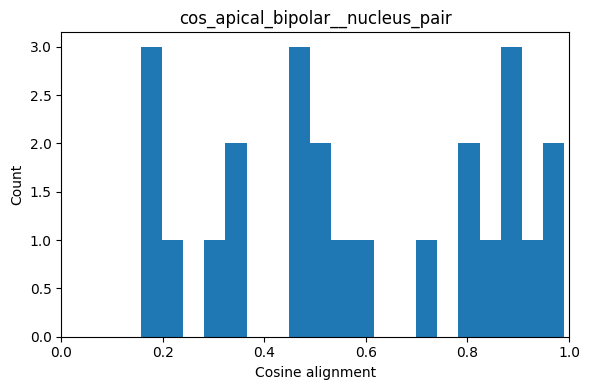


cos_apical_ring__nucleus_pair
Number of valid cells: 24


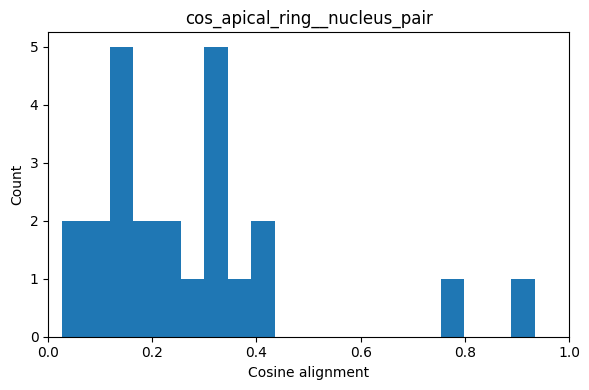


cos_basal_bipolar__nucleus_pair
Number of valid cells: 24


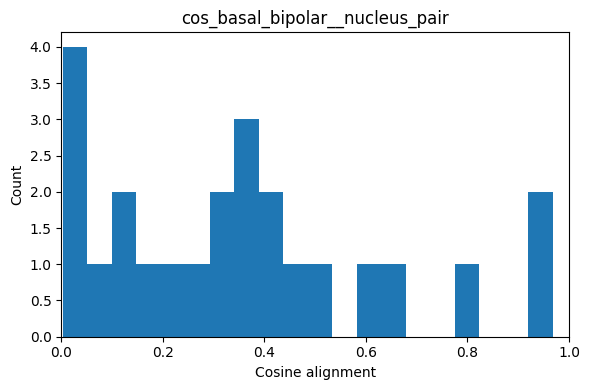


cos_basal_ring__nucleus_pair
Number of valid cells: 24


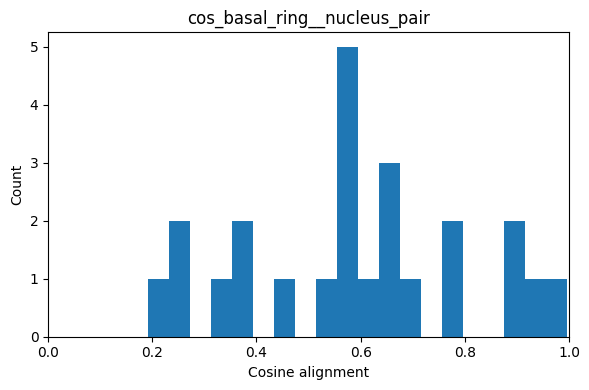


cos_inertia_vec1__nucleus_pair
Number of valid cells: 24


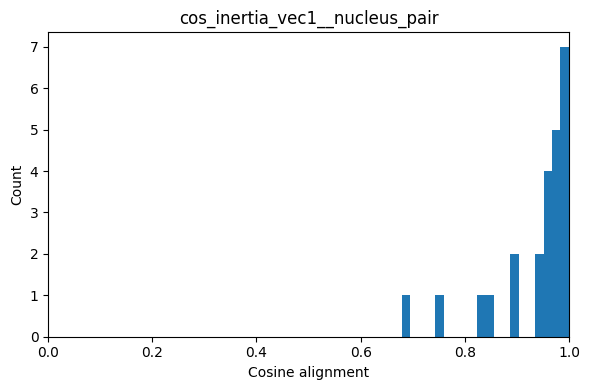


cos_inertia_vec3__nucleus_pair
Number of valid cells: 24


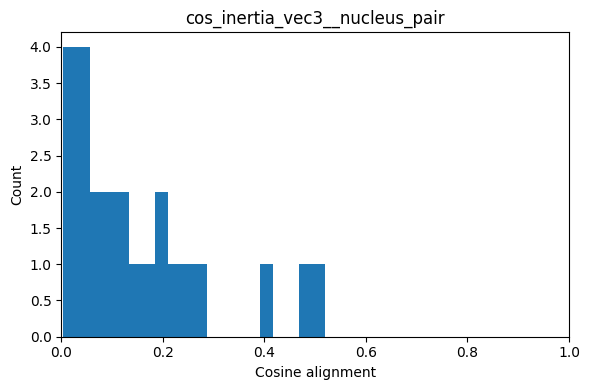


cos_cg_apical_bipolar__nucleus_pair
Number of valid cells: 24


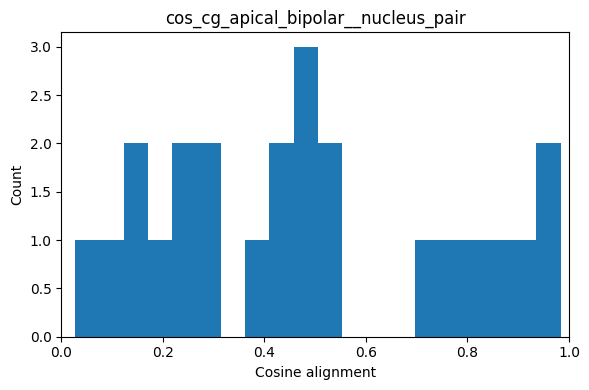


cos_cg_apical_ring__nucleus_pair
Number of valid cells: 24


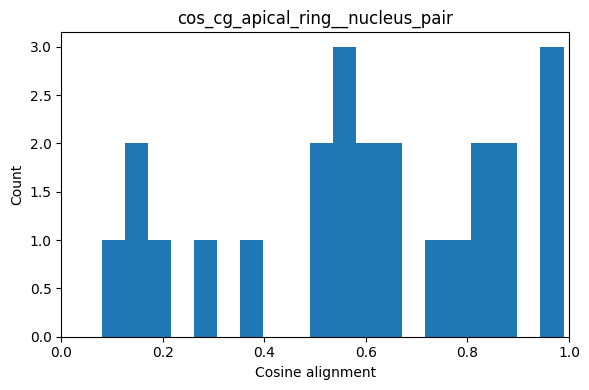


cos_cg_basal_bipolar__nucleus_pair
Number of valid cells: 24


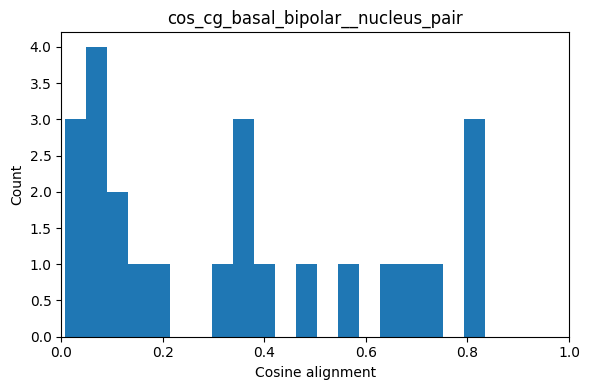


cos_cg_basal_ring__nucleus_pair
Number of valid cells: 24


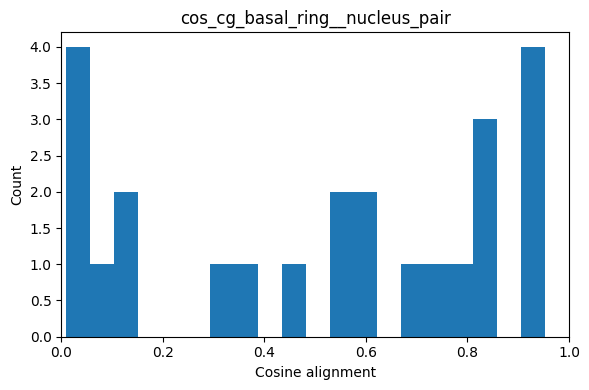


cos_ref_u__nucleus_pair
Number of valid cells: 24


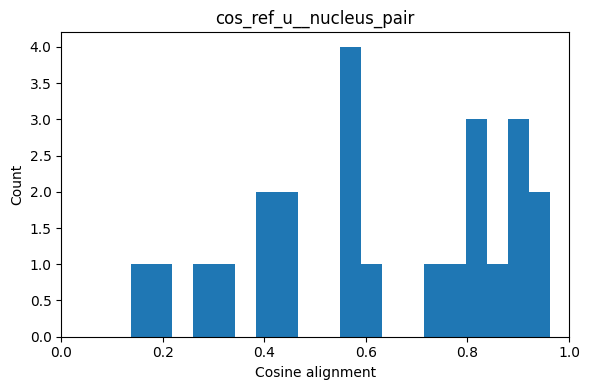


cos_ref_v__nucleus_pair
Number of valid cells: 24


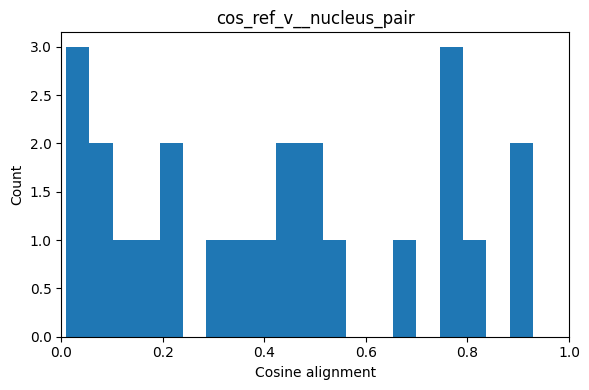


cos_ref_w__nucleus_pair
Number of valid cells: 24


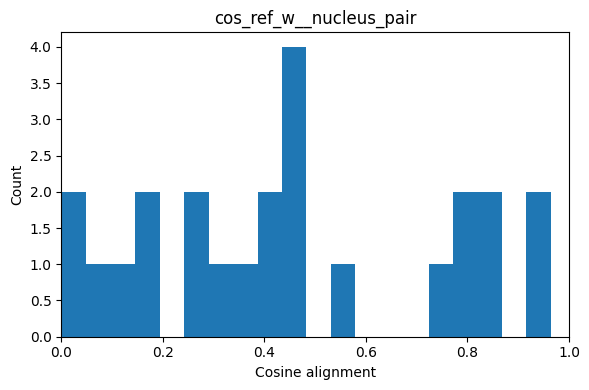

In [37]:
# Find all cosine-feature columns involving nucleus_pair
nucleus_pair_cols = [
    col for col in cosine_features_df.columns
    if "nucleus_pair" in col
]

print("Cosine-feature columns involving nucleus_pair:")
for col in nucleus_pair_cols:
    print(" ", col)

# Plot one histogram per feature
for col in nucleus_pair_cols:
    values = cosine_features_df[col].dropna()

    print(f"\n{col}")
    print("Number of valid cells:", len(values))

    if len(values) == 0:
        print("No valid values. Skipping.")
        continue

    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=20)
    plt.xlabel("Cosine alignment")
    plt.ylabel("Count")
    plt.title(col)
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

In [41]:
# =========================
# Block 13J — Build final node feature table
# =========================

def add_vector_to_row(row, prefix, vec):
    """
    Add a 3D vector to a row dictionary using z, y, x coordinates.
    """
    vec = np.asarray(vec, dtype=float)

    if vec.shape != (3,):
        vec = np.full(3, np.nan)

    row[f"{prefix}_z"] = vec[0]
    row[f"{prefix}_y"] = vec[1]
    row[f"{prefix}_x"] = vec[2]


def add_tensor_to_row(row, prefix, tensor):
    """
    Add a 3x3 tensor to a row dictionary using z, y, x coordinates.
    """
    tensor = np.asarray(tensor, dtype=float)

    if tensor.shape != (3, 3):
        tensor = np.full((3, 3), np.nan)

    coords = ["z", "y", "x"]

    for i, a in enumerate(coords):
        for j, b in enumerate(coords):
            row[f"{prefix}_{a}{b}"] = tensor[i, j]


def add_eigvals_to_row(row, prefix, eigvals):
    """
    Add three eigenvalues to a row dictionary.
    """
    eigvals = np.asarray(eigvals, dtype=float)

    if eigvals.shape != (3,):
        eigvals = np.full(3, np.nan)

    row[f"{prefix}_eigval_1"] = eigvals[0]
    row[f"{prefix}_eigval_2"] = eigvals[1]
    row[f"{prefix}_eigval_3"] = eigvals[2]


def get_first_available(d, keys, default=np.nan):
    """
    Return the first available value from a dictionary.
    """
    if d is None:
        return default

    for key in keys:
        if key in d:
            return d[key]

    return default


def add_cell_geometry_features(row, cid, data, cell_meshes):
    """
    Add basic cell geometry features.
    """
    mesh = cell_meshes.get(cid, None)

    if mesh is None:
        row["cell_volume"] = np.nan
        row["cell_surface_area"] = np.nan
        row["cell_n_vertices"] = np.nan
        row["cell_n_faces"] = np.nan
        add_vector_to_row(row, "cell_mesh_centroid", np.full(3, np.nan))
        add_vector_to_row(row, "cell_mesh_center_mass", np.full(3, np.nan))
        return

    row["cell_volume"] = float(mesh.volume)
    row["cell_surface_area"] = float(mesh.area)
    row["cell_n_vertices"] = int(len(mesh.vertices))
    row["cell_n_faces"] = int(len(mesh.faces))

    add_vector_to_row(row, "cell_mesh_centroid", mesh.centroid)

    try:
        add_vector_to_row(row, "cell_mesh_center_mass", mesh.center_mass)
    except Exception:
        add_vector_to_row(row, "cell_mesh_center_mass", np.full(3, np.nan))

    add_vector_to_row(
        row,
        "cell_topology_centroid",
        data.get("centroid", np.full(3, np.nan))
    )


def add_contact_area_features(row, data):
    """
    Add topological contact area features.
    """
    area_apical = data.get("area_apical", np.nan)
    area_basal = data.get("area_basal", np.nan)
    area_lateral = data.get("area_lateral", np.nan)
    area_border = data.get("area_border", np.nan)
    area_void = data.get("area_void", np.nan)
    area_cv = data.get("area_cv", np.nan)
    area_pv = data.get("area_pv", np.nan)

    area_total_mapped = np.nansum([
        area_apical,
        area_basal,
        area_lateral,
        area_border,
        area_void,
        area_cv,
        area_pv,
    ])

    row["area_apical"] = area_apical
    row["area_basal"] = area_basal
    row["area_lateral"] = area_lateral
    row["area_border"] = area_border
    row["area_void"] = area_void
    row["area_cv"] = area_cv
    row["area_pv"] = area_pv
    row["area_total_mapped"] = area_total_mapped

    if area_total_mapped > 0:
        row["frac_apical"] = area_apical / area_total_mapped
        row["frac_basal"] = area_basal / area_total_mapped
        row["frac_lateral"] = area_lateral / area_total_mapped
        row["frac_border"] = area_border / area_total_mapped
        row["frac_void"] = area_void / area_total_mapped
        row["frac_cv"] = area_cv / area_total_mapped
        row["frac_pv"] = area_pv / area_total_mapped
    else:
        row["frac_apical"] = np.nan
        row["frac_basal"] = np.nan
        row["frac_lateral"] = np.nan
        row["frac_border"] = np.nan
        row["frac_void"] = np.nan
        row["frac_cv"] = np.nan
        row["frac_pv"] = np.nan


def add_single_nucleus_features(row, nucleus, prefix):
    """
    Add features for one nucleus.
    """
    if nucleus is None:
        nucleus = {}

    row[f"{prefix}_id"] = get_first_available(
        nucleus,
        ["nucleus_id", "id", "label_id"],
        default=np.nan
    )

    row[f"{prefix}_type_label"] = get_first_available(
        nucleus,
        ["type_label", "nucleus_type", "raw_label"],
        default=np.nan
    )

    row[f"{prefix}_voxel_count"] = get_first_available(
        nucleus,
        ["voxel_count", "n_voxels"],
        default=np.nan
    )

    row[f"{prefix}_volume"] = get_first_available(
        nucleus,
        ["mesh_volume", "volume"],
        default=np.nan
    )

    row[f"{prefix}_area"] = get_first_available(
        nucleus,
        ["mesh_area", "area", "surface_area"],
        default=np.nan
    )

    add_vector_to_row(
        row,
        f"{prefix}_centroid",
        get_first_available(
            nucleus,
            ["centroid", "centroid_vox"],
            default=np.full(3, np.nan)
        )
    )

    add_vector_to_row(
        row,
        f"{prefix}_mesh_centroid",
        get_first_available(
            nucleus,
            ["mesh_centroid"],
            default=np.full(3, np.nan)
        )
    )

    add_vector_to_row(
        row,
        f"{prefix}_center_mass",
        get_first_available(
            nucleus,
            ["center_mass", "mesh_center_mass"],
            default=np.full(3, np.nan)
        )
    )


def add_nuclear_features(row, nuclei_info):
    """
    Add nuclear features for the hepatocyte.
    """
    if nuclei_info is None:
        nuclei_info = {}

    nuclei_list = nuclei_info.get("nuclei", [])

    if nuclei_list is None:
        nuclei_list = []

    n_nuclei = nuclei_info.get("n_nuclei", len(nuclei_list))

    row["n_nuclei"] = n_nuclei
    row["has_nucleus_pair_vector"] = nuclei_info.get("has_nucleus_pair_vector", False)
    row["nucleus_pair_distance"] = nuclei_info.get("nucleus_pair_distance", np.nan)

    add_vector_to_row(
        row,
        "nucleus_pair_axis",
        nuclei_info.get("nucleus_pair_unit_vector_zyx", np.full(3, np.nan))
    )

    add_vector_to_row(
        row,
        "nucleus_pair_vector",
        nuclei_info.get("nucleus_pair_vector_zyx", np.full(3, np.nan))
    )

    nucleus_volumes = []
    nucleus_areas = []
    nucleus_types = []

    for nucleus in nuclei_list:
        nucleus_volumes.append(get_first_available(nucleus, ["mesh_volume", "volume"], default=np.nan))
        nucleus_areas.append(get_first_available(nucleus, ["mesh_area", "area", "surface_area"], default=np.nan))
        nucleus_types.append(get_first_available(nucleus, ["type_label", "nucleus_type", "raw_label"], default=np.nan))

    if len(nucleus_volumes) > 0:
        row["nucleus_volume_sum"] = np.nansum(nucleus_volumes)
        row["nucleus_volume_mean"] = np.nanmean(nucleus_volumes)
    else:
        row["nucleus_volume_sum"] = np.nan
        row["nucleus_volume_mean"] = np.nan

    if len(nucleus_areas) > 0:
        row["nucleus_area_sum"] = np.nansum(nucleus_areas)
        row["nucleus_area_mean"] = np.nanmean(nucleus_areas)
    else:
        row["nucleus_area_sum"] = np.nan
        row["nucleus_area_mean"] = np.nan

    row["nucleus_type_1"] = nucleus_types[0] if len(nucleus_types) > 0 else np.nan
    row["nucleus_type_2"] = nucleus_types[1] if len(nucleus_types) > 1 else np.nan

    add_single_nucleus_features(
        row,
        nuclei_list[0] if len(nuclei_list) > 0 else None,
        "nucleus_1"
    )

    add_single_nucleus_features(
        row,
        nuclei_list[1] if len(nuclei_list) > 1 else None,
        "nucleus_2"
    )


def add_nematic_features(row, prefix, block):
    """
    Add raw nematic tensor features.
    """
    if block is None:
        block = {}

    row[f"{prefix}_valid"] = block.get("valid", False)
    row[f"{prefix}_n_faces"] = block.get("n_faces", np.nan)
    row[f"{prefix}_spherical_area"] = block.get("spherical_area", np.nan)

    add_tensor_to_row(row, f"{prefix}_tensor", block.get("tensor", np.full((3, 3), np.nan)))
    add_eigvals_to_row(row, prefix, block.get("eigvals", np.full(3, np.nan)))

    add_vector_to_row(row, f"{prefix}_bipolar_axis", block.get("bipolar_axis", np.full(3, np.nan)))
    add_vector_to_row(row, f"{prefix}_ring_axis", block.get("ring_axis", np.full(3, np.nan)))


def add_inertia_features(row, prefix, block):
    """
    Add inertia tensor features.
    """
    if block is None:
        block = {}

    row[f"{prefix}_valid"] = block.get("valid", False)

    add_tensor_to_row(row, f"{prefix}_tensor", block.get("tensor", np.full((3, 3), np.nan)))
    add_eigvals_to_row(row, prefix, block.get("eigvals", np.full(3, np.nan)))

    add_vector_to_row(row, f"{prefix}_vec1", block.get("vec1", np.full(3, np.nan)))
    add_vector_to_row(row, f"{prefix}_vec3", block.get("vec3", np.full(3, np.nan)))


def add_cg_features(row, prefix, block):
    """
    Add coarse-grained tensor features.
    """
    if block is None:
        block = {}

    row[f"{prefix}_valid"] = block.get("valid", False)
    row[f"{prefix}_total_weight"] = block.get("total_weight", np.nan)
    row[f"{prefix}_n_neighbors_used"] = block.get("n_neighbors_used", np.nan)

    add_tensor_to_row(row, f"{prefix}_tensor", block.get("tensor", np.full((3, 3), np.nan)))
    add_eigvals_to_row(row, prefix, block.get("eigvals", np.full(3, np.nan)))

    add_vector_to_row(row, f"{prefix}_vec1", block.get("vec1", np.full(3, np.nan)))
    add_vector_to_row(row, f"{prefix}_vec3", block.get("vec3", np.full(3, np.nan)))


def add_reference_features(row, ref):
    """
    Add PV/CV reference-frame features.
    """
    if ref is None:
        ref = {}

    row["reference_valid"] = ref.get("valid", False)
    row["reference_J_norm"] = ref.get("J_norm", np.nan)

    add_vector_to_row(row, "reference_J", ref.get("J", np.full(3, np.nan)))
    add_vector_to_row(row, "reference_u", ref.get("u", np.full(3, np.nan)))
    add_vector_to_row(row, "reference_v", ref.get("v", np.full(3, np.nan)))
    add_vector_to_row(row, "reference_w", ref.get("w", np.full(3, np.nan)))


# -------------------------
# Build final node feature table
# -------------------------
feature_rows = []

for cid in valid_analysis_ids:

    data = cell_data[cid]

    row = {}

    # Identity and filtering flags
    row["cell_id"] = int(cid)
    row["use_for_physics"] = data.get("use_for_physics", False)
    row["use_for_graph"] = data.get("use_for_graph", False)
    row["is_border_cell"] = data.get("is_border_cell", False)
    row["has_more_than_two_nuclei"] = data.get("has_more_than_two_nuclei", False)

    # Cell geometry
    add_cell_geometry_features(row, cid, data, cell_meshes)

    # Tensor projection center
    physics_raw = data.get("physics_raw", {})

    add_vector_to_row(
        row,
        "projection_center",
        physics_raw.get("projection_center", np.full(3, np.nan))
    )

    # Contact topology
    add_contact_area_features(row, data)

    # Nuclear features
    add_nuclear_features(row, data.get("nuclei", {}))

    # Raw physical tensors
    add_nematic_features(row, "apical", physics_raw.get("apical", {}))
    add_nematic_features(row, "basal", physics_raw.get("basal", {}))
    add_inertia_features(row, "inertia", physics_raw.get("inertia", {}))

    # Coarse-grained physical tensors
    physics_cg = data.get("physics_cg", {})

    add_cg_features(row, "cg_apical_bipolar", physics_cg.get("apical_bipolar", {}))
    add_cg_features(row, "cg_apical_ring", physics_cg.get("apical_ring", {}))
    add_cg_features(row, "cg_basal_bipolar", physics_cg.get("basal_bipolar", {}))
    add_cg_features(row, "cg_basal_ring", physics_cg.get("basal_ring", {}))

    # PV/CV reference frame
    add_reference_features(row, data.get("reference_frame", {}))

    # Axes used for cosine features
    axis_features = data.get("axis_features", {})

    for axis_name, axis_value in axis_features.items():
        add_vector_to_row(row, f"axis_{axis_name}", axis_value)

    # Cosine alignment features
    cosine_features = data.get("cosine_features", {})

    for key, value in cosine_features.items():
        row[key] = value

    feature_rows.append(row)


cell_features_df = pd.DataFrame(feature_rows)


# -------------------------
# Put the most important columns first
# -------------------------
first_cols = [
    "cell_id",
    "use_for_physics",
    "use_for_graph",
    "is_border_cell",
    "has_more_than_two_nuclei",

    "cell_volume",
    "cell_surface_area",
    "cell_n_vertices",
    "cell_n_faces",

    "cell_mesh_centroid_z",
    "cell_mesh_centroid_y",
    "cell_mesh_centroid_x",

    "projection_center_z",
    "projection_center_y",
    "projection_center_x",

    "n_nuclei",
    "has_nucleus_pair_vector",
    "nucleus_pair_distance",

    "area_apical",
    "area_basal",
    "area_lateral",
    "area_void",
    "area_cv",
    "area_pv",
    "area_border",
    "area_total_mapped",

    "frac_apical",
    "frac_basal",
    "frac_lateral",
    "frac_void",
    "frac_cv",
    "frac_pv",
    "frac_border",
]

first_cols = [col for col in first_cols if col in cell_features_df.columns]
remaining_cols = [col for col in cell_features_df.columns if col not in first_cols]

cell_features_df = cell_features_df[first_cols + remaining_cols]


# -------------------------
# Summary
# -------------------------
print("\n==============================")
print("Final node feature table summary")
print("==============================")
print("Rows / graph nodes:", cell_features_df.shape[0])
print("Columns / node features:", cell_features_df.shape[1])

print("\nNuclei counts:")
print(cell_features_df["n_nuclei"].value_counts(dropna=False).sort_index())

print("\nMain validity counts:")
validity_cols = [
    "apical_valid",
    "basal_valid",
    "inertia_valid",
    "cg_apical_bipolar_valid",
    "cg_apical_ring_valid",
    "cg_basal_bipolar_valid",
    "cg_basal_ring_valid",
    "reference_valid",
]

for col in validity_cols:
    if col in cell_features_df.columns:
        print(f"{col}: {int(cell_features_df[col].sum())}")


Final node feature table summary
Rows / graph nodes: 81
Columns / node features: 371

Nuclei counts:
n_nuclei
1    57
2    24
Name: count, dtype: int64

Main validity counts:
apical_valid: 81
basal_valid: 81
inertia_valid: 81
cg_apical_bipolar_valid: 81
cg_apical_ring_valid: 81
cg_basal_bipolar_valid: 81
cg_basal_ring_valid: 81
reference_valid: 81


### Graph

In [44]:
# =========================
# Block 13K — Build final hepatocyte graph
# =========================

valid_set = set(int(cid) for cid in valid_analysis_ids)

special_contact_ids = {
    int(ID_BILE),
    int(ID_SINU),
    int(ID_BORDER),
    int(ID_CV),
    int(ID_PV),
}

G_hepatocytes = nx.Graph()

# -------------------------
# Add nodes with final node features
# -------------------------
node_feature_table = cell_features_df.set_index("cell_id")

for cid in valid_analysis_ids:
    cid = int(cid)

    if cid not in node_feature_table.index:
        print(f"Warning: cell {cid} not found in cell_features_df.")
        continue

    node_attrs = node_feature_table.loc[cid].to_dict()
    node_attrs["cell_id"] = cid

    G_hepatocytes.add_node(cid, **node_attrs)

print("Nodes added:", G_hepatocytes.number_of_nodes())


# -------------------------
# Add edges with only simple edge features
# -------------------------
for cid in tqdm(valid_analysis_ids, desc="Building graph edges"):

    cid = int(cid)

    face_labels = np.asarray(cell_data[cid]["face_labels"])
    face_areas = np.asarray(cell_data[cid]["face_areas"], dtype=float)

    neighbor_ids = np.unique(face_labels)

    for nid in neighbor_ids:
        nid = int(nid)

        # Keep only hepatocyte-hepatocyte contacts
        if nid == 0:
            continue

        if nid == cid:
            continue

        if nid in special_contact_ids:
            continue

        if nid not in valid_set:
            continue

        mask = face_labels == nid

        if not np.any(mask):
            continue

        contact_area = float(np.sum(face_areas[mask]))

        if contact_area <= 0:
            continue

        u, v = sorted([cid, nid])

        if not G_hepatocytes.has_edge(u, v):
            G_hepatocytes.add_edge(
                u,
                v,
                contact_area_total=0.0,
            )

        G_hepatocytes[u][v]["contact_area_total"] += contact_area


# -------------------------
# Add centroid distance to each edge
# -------------------------
for u, v, edge_data in G_hepatocytes.edges(data=True):

    center_u = np.array([
        G_hepatocytes.nodes[u]["projection_center_z"],
        G_hepatocytes.nodes[u]["projection_center_y"],
        G_hepatocytes.nodes[u]["projection_center_x"],
    ], dtype=float)

    center_v = np.array([
        G_hepatocytes.nodes[v]["projection_center_z"],
        G_hepatocytes.nodes[v]["projection_center_y"],
        G_hepatocytes.nodes[v]["projection_center_x"],
    ], dtype=float)

    centroid_distance = np.linalg.norm(center_v - center_u)

    edge_data["centroid_distance"] = float(centroid_distance)


# -------------------------
# Build simple edge feature table
# -------------------------
edge_rows = []

for u, v, edge_data in G_hepatocytes.edges(data=True):
    edge_rows.append({
        "cell_u": u,
        "cell_v": v,
        "contact_area_total": edge_data["contact_area_total"],
        "centroid_distance": edge_data["centroid_distance"],
    })

edge_features_df = pd.DataFrame(edge_rows)


# -------------------------
# Graph summary
# -------------------------
print("\n==============================")
print("Final hepatocyte graph summary")
print("==============================")
print("Nodes:", G_hepatocytes.number_of_nodes())
print("Edges:", G_hepatocytes.number_of_edges())

Nodes added: 81


Building graph edges:   0%|          | 0/81 [00:00<?, ?it/s]


Final hepatocyte graph summary
Nodes: 81
Edges: 223


In [49]:
# =========================
# Block 13L — Visualize final graph and all vector features in Napari
# =========================

VECTOR_SCALE = 35.0
VECTOR_EDGE_WIDTH = 1.6

GRAPH_EDGE_WIDTH = 1.2
NODE_SIZE = 5


def get_node_center(G, cid):
    """
    Get the projection center of a graph node.
    """
    node = G.nodes[cid]

    center = np.array([
        node.get("projection_center_z", np.nan),
        node.get("projection_center_y", np.nan),
        node.get("projection_center_x", np.nan),
    ], dtype=float)

    return center


def get_node_vector(G, cid, prefix):
    """
    Get a normalized 3D vector from node attributes.
    """
    node = G.nodes[cid]

    vec = np.array([
        node.get(f"{prefix}_z", np.nan),
        node.get(f"{prefix}_y", np.nan),
        node.get(f"{prefix}_x", np.nan),
    ], dtype=float)

    return normalize_vector(vec)


def build_vectors_from_center(G, prefix, scale=35.0):
    """
    Build Napari vectors using the same convention as Block 13H.

    entry[0] = cell center
    entry[1] = axis direction multiplied by scale
    """
    vectors = []

    for cid in G.nodes:
        center = get_node_center(G, cid)
        vec = get_node_vector(G, cid, prefix)

        if np.any(np.isnan(center)) or np.any(np.isnan(vec)):
            continue

        entry = np.zeros((2, 3), dtype=float)
        entry[0] = center
        entry[1] = vec * scale

        vectors.append(entry)

    if len(vectors) == 0:
        return np.zeros((0, 2, 3), dtype=float)

    return np.stack(vectors, axis=0)


def build_graph_edge_vectors(G):
    """
    Build graph edges as Napari vectors from one hepatocyte center to another.
    """
    vectors = []

    for u, v in G.edges:
        center_u = get_node_center(G, u)
        center_v = get_node_center(G, v)

        if np.any(np.isnan(center_u)) or np.any(np.isnan(center_v)):
            continue

        entry = np.zeros((2, 3), dtype=float)
        entry[0] = center_u
        entry[1] = center_v - center_u

        vectors.append(entry)

    if len(vectors) == 0:
        return np.zeros((0, 2, 3), dtype=float)

    return np.stack(vectors, axis=0)


def build_node_points(G):
    """
    Build node point coordinates from graph node centers.
    """
    points = []

    for cid in G.nodes:
        center = get_node_center(G, cid)

        if np.any(np.isnan(center)):
            continue

        points.append(center)

    if len(points) == 0:
        return np.zeros((0, 3), dtype=float)

    return np.asarray(points, dtype=float)


# -------------------------
# Vector layers
# -------------------------
vector_layers = [
    ("axis_apical_bipolar", "Apical bipolar axis", "red"),
    ("axis_apical_ring", "Apical ring axis", "orange"),

    ("axis_basal_bipolar", "Basal bipolar axis", "blue"),
    ("axis_basal_ring", "Basal ring axis", "cyan"),

    ("axis_inertia_vec1", "Inertia vec1", "yellow"),
    ("axis_inertia_vec3", "Inertia vec3", "magenta"),

    ("axis_cg_apical_bipolar", "CG apical bipolar axis", "lime"),
    ("axis_cg_apical_ring", "CG apical ring axis", "green"),

    ("axis_cg_basal_bipolar", "CG basal bipolar axis", "purple"),
    ("axis_cg_basal_ring", "CG basal ring axis", "pink"),

    ("axis_ref_u", "Reference u", "white"),
    ("axis_ref_v", "Reference v = PV/CV field", "gold"),
    ("axis_ref_w", "Reference w", "gray"),

    ("axis_nucleus_pair", "Nucleus pair axis", "brown"),
]


# -------------------------
# Build graph objects
# -------------------------
node_points = build_node_points(G_hepatocytes)
edge_vectors = build_graph_edge_vectors(G_hepatocytes)

print("Graph nodes:", len(node_points))
print("Graph edges:", len(edge_vectors))


# -------------------------
# Open Napari viewer
# -------------------------
viewer = napari.Viewer(title="Final hepatocyte graph and vector features")
viewer.dims.ndisplay = 3

# Optional context
viewer.add_labels(
    hepa_img,
    name="Hepatocyte labels",
    opacity=0.12,
    visible=False,
)

# Nodes
viewer.add_points(
    node_points,
    name="Graph nodes / hepatocyte centers",
    size=NODE_SIZE,
    opacity=0.9,
    visible=True,
)

# Edges
if len(edge_vectors) > 0:
    viewer.add_vectors(
        edge_vectors,
        name="Graph edges / hepatocyte contacts",
        edge_width=GRAPH_EDGE_WIDTH,
        length=1.0,
        edge_color="white",
        visible=True,
    )

# Vector layers
for prefix, name, color in vector_layers:

    vectors = build_vectors_from_center(
        G_hepatocytes,
        prefix=prefix,
        scale=VECTOR_SCALE,
    )

    print(f"{name}: {len(vectors)} vectors")

    if len(vectors) == 0:
        continue

    viewer.add_vectors(
        vectors,
        name=name,
        edge_width=VECTOR_EDGE_WIDTH,
        length=1.0,
        edge_color=color,
        visible=False,
    )

Graph nodes: 81
Graph edges: 223
Apical bipolar axis: 81 vectors
Apical ring axis: 81 vectors
Basal bipolar axis: 81 vectors
Basal ring axis: 81 vectors
Inertia vec1: 81 vectors
Inertia vec3: 81 vectors
CG apical bipolar axis: 81 vectors
CG apical ring axis: 81 vectors
CG basal bipolar axis: 81 vectors
CG basal ring axis: 81 vectors
Reference u: 81 vectors
Reference v = PV/CV field: 81 vectors
Reference w: 81 vectors
Nucleus pair axis: 24 vectors
